# Tarea 1 — Segmentación retórica (v3: ZS + FS para Llama y GPT, SciBETO con 4 epochs)

**Cambios respecto a v2:**
- SciBETO: `EPOCHS = 4` (era 6) — converge antes con la nueva preprocessing pipeline.
- Llama 3.1 8B: ahora evalúa **zero-shot** Y **few-shot** (antes solo FS).
- GPT-4o-mini: ahora evalúa **zero-shot** Y **few-shot** (antes solo FS).
- Comparación final con **5 filas**: SciBETO + 4 variantes de LLM.
- Matrices de confusión: 5 plots (1 por modelo).

El backend de la demo (`maia-g2.duckdns.org`) integrará los 4 LLMs según los resultados de este notebook.


## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#Login  W&B
from google.colab import userdata
import wandb

wandb.login(key=userdata.get("WANDB_API_KEY"))

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: edwincifuentes (natamoncada10-universidad-de-los-andes) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
!pip install -q transformers datasets evaluate accelerate scikit-learn bitsandbytes openai tenacity seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 45.9 MB/s eta 0:00:00


In [4]:
import os, json, shutil, re, time, asyncio, random, gc
from collections import Counter
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer, AutoConfig, AutoModelForSequenceClassification, AutoModelForCausalLM,
    TrainingArguments, Trainer, EarlyStoppingCallback, BitsAndBytesConfig, set_seed,
)
import evaluate
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from scipy.spatial.distance import jensenshannon

# Reproducibilidad
SEED = 42
set_seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# Visualización
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

# Configuración global
VERSION = 'v4'
EXCLUDE_CONTR = True
BASE_LABELS = ['INTRO', 'BACK', 'METH', 'RES', 'DISC', 'CONTR', 'LIM', 'CONC']
LABELS = [l for l in BASE_LABELS if l != 'CONTR'] if EXCLUDE_CONTR else BASE_LABELS
label2id = {l: i for i, l in enumerate(LABELS)}
id2label = {i: l for i, l in enumerate(LABELS)}
n_classes = len(LABELS)

# Rutas
DATA_DIR    = '/content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/maia_datasets'
RESULTS_DIR = '/content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab'
MODELS_DIR  = f'{RESULTS_DIR}/scibeto-t1-7c-{VERSION}' if EXCLUDE_CONTR else f'{RESULTS_DIR}/scibeto-t1-8c-{VERSION}'
PLOTS_DIR   = f'{RESULTS_DIR}/plots_{VERSION}'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

print(f"Versión: {VERSION}")
print(f"PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB)")
print(f"Clases activas ({n_classes}): {LABELS}")
print(f"Resultados en: {RESULTS_DIR}")
print(f"Plots en:      {PLOTS_DIR}")

Versión: v4
PyTorch: 2.10.0+cu128 | CUDA: True
GPU: NVIDIA A100-SXM4-40GB (39.5 GB)
Clases activas (7): ['INTRO', 'BACK', 'METH', 'RES', 'DISC', 'LIM', 'CONC']
Resultados en: /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab
Plots en:      /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/plots_v4


## 2. EDA diagnóstico — carga cruda y verificación del mismatch

Cargamos los CSVs originales (sin transformar) y reproducimos los hallazgos clave que motivaron esta nueva versión. Si los flags se disparan, procedemos al refactor. Si no, abortamos y reportamos.

In [5]:
# Listado SOFT_MASK que ya usábamos — sirve para diagnosticar y para re-enmascarar después
SOFT_MASK_KEYWORDS = [
    'introducción', 'introduccion', 'objetivos', 'justificacion', 'justificación',
    'antecedentes', 'estado del arte', 'metodología', 'metodologia',
    'materiales y métodos', 'resultados', 'discusión', 'discusion',
    'conclusiones', 'trabajo futuro', 'limitaciones', 'recomendaciones',
]
SOFT_MASK_KEYWORDS.sort(key=len, reverse=True)
_MASK_PATTERNS = [(re.compile(rf'\b{re.escape(kw)}\b', re.IGNORECASE), '[MASK]')
                  for kw in SOFT_MASK_KEYWORDS]

def apply_soft_mask(text: str) -> str:
    out = str(text)
    for pat, repl in _MASK_PATTERNS:
        out = pat.sub(repl, out)
    return re.sub(r'\s+', ' ', out).strip()

# Cargar crudo conservando todas las columnas
def load_raw(csv_path):
    df = pd.read_csv(csv_path)
    if EXCLUDE_CONTR: df = df[df['category'] != 'CONTR'].copy()
    df = df.dropna(subset=['snippet']).copy()
    return df

train_raw = load_raw(f'{DATA_DIR}/dataset_train.csv')
val_raw   = load_raw(f'{DATA_DIR}/dataset_val.csv')
test_raw  = load_raw(f'{DATA_DIR}/dataset_test.csv')

print(f"Crudo: train={len(train_raw):,d}  val={len(val_raw):,d}  test={len(test_raw):,d}")
print(f"Columnas: {list(train_raw.columns)}")

Crudo: train=10,694  val=1,906  test=1,400
Columnas: ['source_file', 'category', 'snippet', 'word_count', 'matched_keywords', 'regex_score', 'neutralized_snippet']


In [6]:
# Helpers de EDA
_WORD_RE    = re.compile(r"\b\w+\b", re.UNICODE)
_MASK_RE    = re.compile(r"\[MASK\]")
_KEYWORD_RE = re.compile(r"\b(" + "|".join(re.escape(kw) for kw in SOFT_MASK_KEYWORDS) + r")\b",
                         re.IGNORECASE)

def featurize(df, split_name):
    snip = df['snippet'].astype(str)
    neut = df['neutralized_snippet'].fillna(df['snippet']).astype(str)
    return pd.DataFrame({
        'split': split_name, 'category': df['category'].values,
        'len_words':       snip.map(lambda s: len(_WORD_RE.findall(s))).values,
        'n_mask_in_neut':  neut.map(lambda s: len(_MASK_RE.findall(s))).values,
        'n_kw_residual':   neut.map(lambda s: len(_KEYWORD_RE.findall(s))).values,
        'regex_score':     df['regex_score'].values,
    })

feat_train = featurize(train_raw, 'train')
feat_val   = featurize(val_raw,   'val')
feat_test  = featurize(test_raw,  'test')
feat_all   = pd.concat([feat_train, feat_val, feat_test], ignore_index=True)

print("="*70); print("EJE A — Longitud (palabras, sobre snippet sin mask)"); print("="*70)
print(feat_all.groupby('split')['len_words'].describe(percentiles=[.05,.25,.5,.75,.95]).round(0).to_string())

EJE A — Longitud (palabras, sobre snippet sin mask)
         count   mean    std    min     5%    25%    50%    75%     95%     max
split                                                                          
test    1400.0  310.0  345.0    6.0   44.0   83.0  246.0  367.0   908.0  3198.0
train  10694.0  800.0  109.0  188.0  735.0  749.0  761.0  795.0  1024.0  1509.0
val     1906.0  801.0  105.0  280.0  735.0  748.0  759.0  793.0  1025.0  1357.0


In [7]:
print("="*70); print("EJE B — Comportamiento del [MASK] y residuales"); print("="*70)
print(feat_all.groupby('split').agg(
    pct_with_mask    = ('n_mask_in_neut', lambda x: f'{(x>0).mean()*100:.1f}%'),
    mean_masks       = ('n_mask_in_neut', 'mean'),
    pct_kw_residual  = ('n_kw_residual',  lambda x: f'{(x>0).mean()*100:.1f}%'),
).round(2).to_string())

print("\n% snippets con keyword SOFT_MASK RESIDUAL en neutralized_snippet (clase × split):")
print(feat_all.assign(has_resid=feat_all['n_kw_residual']>0)
              .pivot_table(index='category', columns='split', values='has_resid',
                           aggfunc=lambda x: x.mean()*100)
              .reindex(LABELS).round(1).to_string())

EJE B — Comportamiento del [MASK] y residuales
      pct_with_mask  mean_masks pct_kw_residual
split                                          
test          83.6%        6.78           33.8%
train        100.0%        4.30           68.8%
val          100.0%        4.26           68.7%

% snippets con keyword SOFT_MASK RESIDUAL en neutralized_snippet (clase × split):
split     test  train   val
category                   
INTRO     33.0   86.5  87.5
BACK      45.3   64.6  60.9
METH      48.5   84.6  84.9
RES       28.0   64.7  67.3
DISC      14.5   55.5  54.4
LIM       27.5   55.5  54.4
CONC      39.7   70.3  71.9


In [8]:
print("="*70); print("EJE F — Metadatos del extractor"); print("="*70)
print("\nregex_score por split (top 5 valores):")
for name, df in [('train', train_raw), ('val', val_raw), ('test', test_raw)]:
    vc = df['regex_score'].value_counts().sort_index()
    top5 = vc.head(5).to_dict()
    print(f"  {name}: unique={df['regex_score'].nunique()}, top5={top5}")

# Overlap matched_keywords ↔ SOFT_MASK_KEYWORDS
def kw_in_softmask(s):
    if not isinstance(s, str): return 0, 0
    ks = [k.strip().lower() for k in s.split(',')]
    return sum(1 for k in ks if k in SOFT_MASK_KEYWORDS), len(ks)

print("\nOverlap matched_keywords con listado SOFT_MASK:")
for name, df in [('train', train_raw), ('val', val_raw), ('test', test_raw)]:
    pairs = df['matched_keywords'].apply(kw_in_softmask)
    total = sum(p[1] for p in pairs); in_list = sum(p[0] for p in pairs)
    print(f"  {name}: {in_list}/{total} entries ({100*in_list/max(total,1):.1f}%) están en SOFT_MASK")

EJE F — Metadatos del extractor

regex_score por split (top 5 valores):
  train: unique=37, top5={2: 3752, 3: 2030, 4: 1763, 5: 1011, 6: 596}
  val: unique=28, top5={2: 669, 3: 350, 4: 319, 5: 210, 6: 108}
  test: unique=1, top5={0: 1400}

Overlap matched_keywords con listado SOFT_MASK:
  train: 6808/25959 entries (26.2%) están en SOFT_MASK
  val: 1183/4585 entries (25.8%) están en SOFT_MASK
  test: 372/8489 entries (4.4%) están en SOFT_MASK


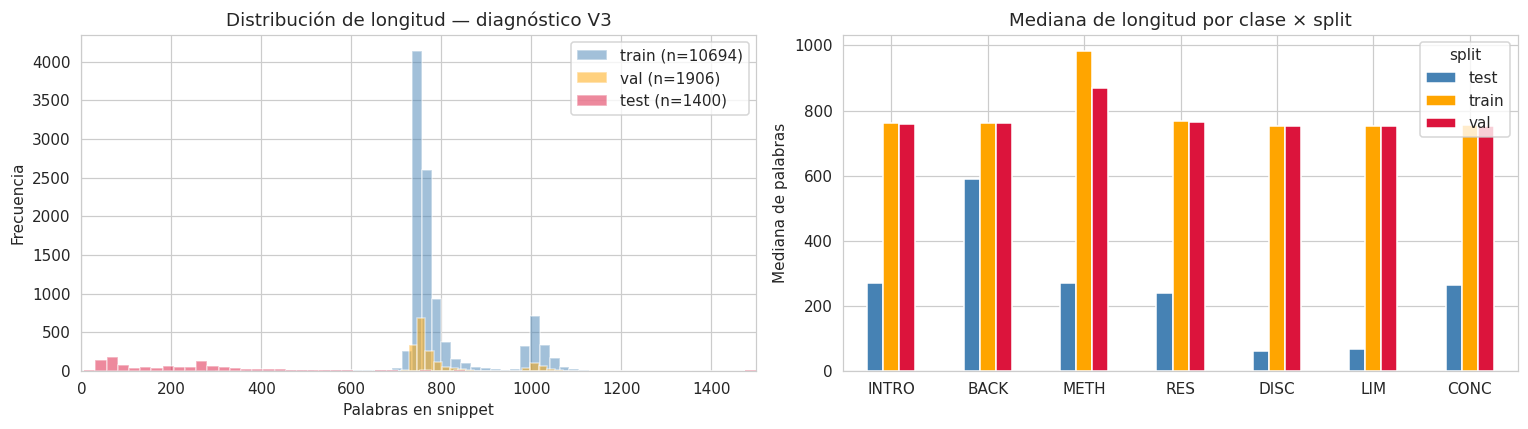

In [9]:
# Visualización del mismatch de longitudes
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
for split, color in [('train','steelblue'), ('val','orange'), ('test','crimson')]:
    data = feat_all[feat_all['split']==split]['len_words'].clip(upper=1500)
    ax.hist(data, bins=60, alpha=0.5, label=f'{split} (n={len(data)})', color=color)
ax.set_xlabel('Palabras en snippet'); ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de longitud — diagnóstico V3')
ax.legend(); ax.set_xlim(0, 1500)

ax = axes[1]
medians = feat_all.pivot_table(index='category', columns='split',
                                values='len_words', aggfunc='median').reindex(LABELS)
medians.plot(kind='bar', ax=ax, color=['steelblue','orange','crimson'])
ax.set_ylabel('Mediana de palabras'); ax.set_title('Mediana de longitud por clase × split')
ax.set_xlabel(''); ax.legend(title='split')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/eda_length_mismatch.png', bbox_inches='tight')
plt.show()

In [10]:
# Auto-diagnóstico — banderas que motivan el refactor
print("="*70); print("AUTO-DIAGNÓSTICO"); print("="*70)
flags = []

mt = feat_train['len_words'].median(); ms = feat_test['len_words'].median()
if abs(mt-ms)/max(mt,1) > 0.30:
    flags.append(f"⚠️  LONGITUD: mediana train={mt:.0f}w vs test={ms:.0f}w "
                 f"({(mt-ms)/ms*100:+.0f}% diferencia) → motiva truncación")

pkr_train = (feat_train['n_kw_residual']>0).mean()*100
pkr_test  = (feat_test['n_kw_residual']>0).mean()*100
if abs(pkr_train - pkr_test) > 10:
    flags.append(f"⚠️  MASK: residuales train {pkr_train:.1f}% vs test {pkr_test:.1f}% "
                 f"→ motiva re-aplicar máscara simétrica")

score_test = (test_raw['regex_score']==0).mean()*100
if score_test > 90:
    flags.append(f"⚠️  PIPELINE: test tiene regex_score=0 en {score_test:.0f}% "
                 f"(train tiene varianza) → confirma pipelines distintos")

if flags:
    for f in flags: print(f)
    print("\n→ Procediendo al refactor del train.")
else:
    print("✅ Sin banderas críticas. Considerar abortar refactor.")

AUTO-DIAGNÓSTICO
⚠️  LONGITUD: mediana train=761w vs test=246w (+210% diferencia) → motiva truncación
⚠️  MASK: residuales train 68.8% vs test 33.8% → motiva re-aplicar máscara simétrica
⚠️  PIPELINE: test tiene regex_score=0 en 100% (train tiene varianza) → confirma pipelines distintos

→ Procediendo al refactor del train.


## 3. Refactor del train

Tres intervenciones secuenciales sobre `dataset_train.csv` y `dataset_val.csv`. El test queda intacto en cuanto a su selección de snippets — solo se le re-aplicará la máscara `apply_soft_mask` en el momento de cargarlo para entrenamiento (sección 4).

### 3.1 Filtro de frontmatter académico

Detecta portadas de tesis / dedicatorias / agradecimientos que el extractor regex incluyó por error. El umbral (≥2 patrones en el primer 30 % del texto) se calibró para conservar 82 % del train y descartar solo 0.1 % del test (control de especificidad).

In [11]:
_FRONTMATTER_PATTERNS = [
    re.compile(r'\bORCID\b'),
    re.compile(r'\bdedicatoria\b', re.IGNORECASE),
    re.compile(r'\bagradecimiento[s]?\b', re.IGNORECASE),
    re.compile(r'\bjurado[s]?\b', re.IGNORECASE),
    re.compile(r'\basesor(a|es|as)?\b', re.IGNORECASE),
    re.compile(r'\bamor\s+(incondicional|infinito)\b', re.IGNORECASE),
    re.compile(r'\boptar\s+(al|por|el)\s+(el\s+)?(t[ií]tulo|grado)\b', re.IGNORECASE),
    re.compile(r'\bDra?\.\s+[A-ZÁ-Ú][a-záéíóúñ]+', re.UNICODE),
    re.compile(r'\bincondicional\b', re.IGNORECASE),
    re.compile(r'\b(maestr[íi]a|doctorado|pregrado|licenciatura)\s+en\b', re.IGNORECASE),
    re.compile(r'\bFacultad\s+de\b', re.IGNORECASE),
    re.compile(r'\bcl[áa]usula\s+de\b', re.IGNORECASE),
]

FRONTMATTER_THRESHOLD = 2
FRONTMATTER_HEAD_FRAC = 0.30

def frontmatter_score(text):
    if not isinstance(text, str): return 0
    head = text[:int(len(text) * FRONTMATTER_HEAD_FRAC)] if len(text) > 200 else text
    return sum(1 for p in _FRONTMATTER_PATTERNS if p.search(head))

def is_frontmatter(text):
    return frontmatter_score(text) >= FRONTMATTER_THRESHOLD

# Calcular y reportar
for name, df in [('train', train_raw), ('val', val_raw), ('test', test_raw)]:
    scores = df['snippet'].apply(frontmatter_score)
    n_drop = (scores >= FRONTMATTER_THRESHOLD).sum()
    print(f"{name}: {n_drop:>4d} de {len(df):>5d} filas marcadas frontmatter "
          f"({100*n_drop/len(df):.1f}%)")

# Por clase en train
print("\nFiltrado por clase en TRAIN:")
fm_train = train_raw.assign(fm_score=train_raw['snippet'].apply(frontmatter_score))
print(fm_train.groupby('category').agg(
    n=('fm_score', 'size'),
    fm_2plus=('fm_score', lambda x: (x >= 2).sum()),
    pct=('fm_score', lambda x: f'{100*(x>=2).mean():.1f}%')
).to_string())

train: 1924 de 10694 filas marcadas frontmatter (18.0%)
val:  321 de  1906 filas marcadas frontmatter (16.8%)
test:    2 de  1400 filas marcadas frontmatter (0.1%)

Filtrado por clase en TRAIN:
             n  fm_2plus    pct
category                       
BACK      1516       264  17.4%
CONC      1540       182  11.8%
DISC      1539        75   4.9%
INTRO     1529       527  34.5%
LIM       1517        60   4.0%
METH      1528       528  34.6%
RES       1525       288  18.9%


### 3.2 Truncación centrada en el anchor del extractor

Trunca cada snippet a una ventana de ~240w (con jitter ±160w para reproducir la varianza del test) centrada en el primer `matched_keyword`. Si el snippet ya es corto, se conserva tal cual. Si no hay anchor, se toma desde el inicio.

In [12]:
_SENT_SPLIT = re.compile(r'(?<=[.!?])\s+')

TARGET_WORDS = 240
JITTER       = 160
MIN_WORDS    = 40

def truncate_around_anchor(snippet, matched_kws,
                           target_words=TARGET_WORDS, jitter=JITTER, min_words=MIN_WORDS,
                           rng=None):
    """Trunca snippet a ~target_words ± jitter, centrado en primer matched_keyword."""
    if not isinstance(snippet, str): return snippet
    words = snippet.split()
    if len(words) <= target_words + jitter:
        return snippet

    if rng is None: rng = np.random
    actual_target = max(min_words, target_words + int(rng.randint(-jitter, jitter + 1)))

    anchor_word_pos = None
    if isinstance(matched_kws, str) and matched_kws.strip():
        for kw in [k.strip() for k in matched_kws.split(',') if k.strip()]:
            char_pos = snippet.lower().find(kw.lower())
            if char_pos >= 0:
                anchor_word_pos = len(snippet[:char_pos].split())
                break

    if anchor_word_pos is None:
        start, end = 0, actual_target
    else:
        start = max(0, anchor_word_pos - actual_target // 2)
        end = min(len(words), start + actual_target)
        if end - start < actual_target:
            start = max(0, end - actual_target)

    return ' '.join(words[start:end])

# Smoke test
rng_test = np.random.RandomState(SEED)
sample = train_raw.iloc[0]
truncated = truncate_around_anchor(sample['snippet'], sample['matched_keywords'], rng=rng_test)
print(f"Ejemplo train[0] ({sample['category']}):")
print(f"  Original:  {len(sample['snippet'].split())} palabras")
print(f"  Truncado:  {len(truncated.split())} palabras")
print(f"  matched_keywords: {sample['matched_keywords']}")

Ejemplo train[0] (BACK):
  Original:  744 palabras
  Truncado:  182 palabras
  matched_keywords: según lo, estado del arte, según el, según la


### 3.3 Aplicación combinada: filtrar + truncar + re-enmascarar simétricamente

In [13]:
def refactor_split(df, split_name, rng):
    """Aplica filtro de frontmatter + truncación + re-mask sobre un DataFrame."""
    n0 = len(df)
    # 1. Filtrar frontmatter
    df = df[df['snippet'].apply(frontmatter_score) < FRONTMATTER_THRESHOLD].copy()
    n1 = len(df)
    # 2. Truncar
    df['snippet'] = df.apply(
        lambda r: truncate_around_anchor(r['snippet'], r['matched_keywords'], rng=rng),
        axis=1)
    # 3. Re-aplicar máscara simétrica (V2-style)
    df['neutralized_snippet'] = df['snippet'].astype(str).apply(apply_soft_mask)
    # Actualizar word_count para reflejar truncación
    df['word_count'] = df['snippet'].str.split().str.len()
    print(f"{split_name}: {n0:>5d} → {n1:>5d} (filtro frontmatter -{n0-n1}) → "
          f"{len(df)} filas (truncación + re-mask)")
    return df

rng = np.random.RandomState(SEED)
train_v4 = refactor_split(train_raw, 'train', rng)
val_v4   = refactor_split(val_raw,   'val',   rng)

# Test: NO se filtra frontmatter (es human-annotated, ya limpio).
#        SÍ se re-aplica la máscara para que sea simétrica con train.
test_v4 = test_raw.copy()
test_v4['neutralized_snippet'] = test_v4['snippet'].astype(str).apply(apply_soft_mask)
test_v4['word_count'] = test_v4['snippet'].str.split().str.len()
print(f"test:  {len(test_raw):>5d} → {len(test_v4)} filas (solo re-mask, sin filtro ni truncación)")

train: 10694 →  8770 (filtro frontmatter -1924) → 8770 filas (truncación + re-mask)
val:  1906 →  1585 (filtro frontmatter -321) → 1585 filas (truncación + re-mask)
test:   1400 → 1400 filas (solo re-mask, sin filtro ni truncación)


In [14]:
# Persistir los CSVs limpios al Drive
out_train = f'{DATA_DIR}/dataset_train_v4.csv'
out_val   = f'{DATA_DIR}/dataset_val_v4.csv'
out_test  = f'{DATA_DIR}/dataset_test_v4.csv'

train_v4.to_csv(out_train, index=False)
val_v4.to_csv(out_val, index=False)
test_v4.to_csv(out_test, index=False)

for p in [out_train, out_val, out_test]:
    size_mb = os.path.getsize(p) / 1024 / 1024
    print(f'💾 {p}  ({size_mb:.1f} MB)')

💾 /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/maia_datasets/dataset_train_v4.csv  (27.5 MB)
💾 /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/maia_datasets/dataset_val_v4.csv  (5.0 MB)
💾 /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/maia_datasets/dataset_test_v4.csv  (5.5 MB)


### 3.4 Comparación pre / post refactor

In [15]:
# Tabla comparativa antes/después
def quick_stats(df, label):
    lens = df['snippet'].astype(str).str.split().str.len()
    masks = df['neutralized_snippet'].astype(str).str.count(r'\[MASK\]')
    return {
        'split':        label,
        'n':            len(df),
        'len_p5':       lens.quantile(0.05),
        'len_p50':      lens.quantile(0.5),
        'len_p95':      lens.quantile(0.95),
        'mean_masks':   masks.mean(),
        'pct_w_mask':   (masks > 0).mean()*100,
    }

rows = [
    quick_stats(train_raw, 'train_V3'),
    quick_stats(train_v4,  'train_V4'),
    quick_stats(val_raw,   'val_V3'),
    quick_stats(val_v4,    'val_V4'),
    quick_stats(test_raw,  'test_V3'),
    quick_stats(test_v4,   'test_V4'),
]
comp_df = pd.DataFrame(rows).round(1)
print(comp_df.to_string(index=False))

   split     n  len_p5  len_p50  len_p95  mean_masks  pct_w_mask
train_V3 10694   737.0    750.0   1000.0         4.3       100.0
train_V4  8770    95.0    239.0    385.0         1.4        58.5
  val_V3  1906   737.0    749.0   1000.0         4.3       100.0
  val_V4  1585    97.0    243.0    386.0         1.4        57.7
 test_V3  1400    44.0    244.0    906.0         6.8        83.6
 test_V4  1400    44.0    244.0    906.0         0.9        40.9


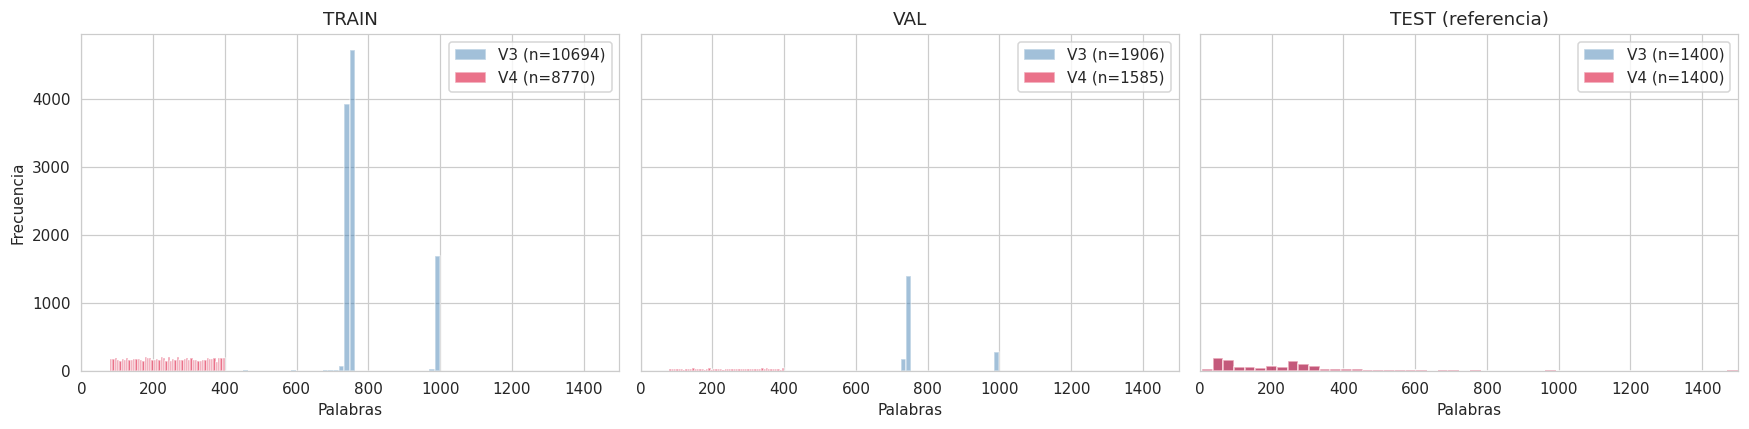

In [16]:
# Histograma comparativo de longitudes
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, (raw, v4, name) in zip(axes, [
    (train_raw, train_v4, 'TRAIN'),
    (val_raw,   val_v4,   'VAL'),
    (test_raw,  test_v4,  'TEST (referencia)'),
]):
    lens_v3 = raw['snippet'].astype(str).str.split().str.len().clip(upper=1500)
    lens_v4 = v4['snippet'].astype(str).str.split().str.len().clip(upper=1500)
    ax.hist(lens_v3, bins=50, alpha=0.5, label=f'V3 (n={len(raw)})', color='steelblue')
    ax.hist(lens_v4, bins=50, alpha=0.6, label=f'V4 (n={len(v4)})', color='crimson')
    ax.set_xlabel('Palabras'); ax.set_title(name); ax.legend(); ax.set_xlim(0, 1500)
axes[0].set_ylabel('Frecuencia')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/refactor_length_comparison.png', bbox_inches='tight')
plt.show()

## 4. Carga de datos refactorizada para entrenamiento

Ahora cargamos los CSVs limpios y construimos `train_df`, `val_df`, `test_df` con el schema mínimo que requiere SciBETO + los LLMs.

In [17]:
def load_v4(csv_path):
    df = pd.read_csv(csv_path)
    if EXCLUDE_CONTR: df = df[df['category'] != 'CONTR'].copy()
    df = df.dropna(subset=['snippet','neutralized_snippet']).copy()
    df['label'] = df['category'].map(label2id)
    df = df[df['label'].notna()].copy()
    df['label'] = df['label'].astype(int)
    return df[['snippet', 'neutralized_snippet', 'category', 'label']].reset_index(drop=True)

train_df = load_v4(f'{DATA_DIR}/dataset_train_v4.csv')
val_df   = load_v4(f'{DATA_DIR}/dataset_val_v4.csv')
test_df  = load_v4(f'{DATA_DIR}/dataset_test_v4.csv')

print(f"Train: {len(train_df):,d} | Val: {len(val_df):,d} | Test: {len(test_df):,d}\n")
print('Distribución TRAIN V4:'); print(train_df['category'].value_counts().sort_index().to_string())
print('\nDistribución TEST V4:'); print(test_df['category'].value_counts().sort_index().to_string())

Train: 8,770 | Val: 1,585 | Test: 1,400

Distribución TRAIN V4:
category
BACK     1252
CONC     1358
DISC     1464
INTRO    1002
LIM      1457
METH     1000
RES      1237

Distribución TEST V4:
category
BACK     201
CONC     199
DISC     200
INTRO    200
LIM      200
METH     200
RES      200


## 5. Métricas y parser robusto para LLMs

In [18]:
f1_metric = evaluate.load('f1')
accuracy_metric = evaluate.load('accuracy')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_metric.compute(predictions=preds, references=labels)['accuracy'],
        'f1_macro': f1_metric.compute(predictions=preds, references=labels, average='macro')['f1'],
        'f1_micro': f1_metric.compute(predictions=preds, references=labels, average='micro')['f1'],
    }

_LLM_LABEL_MAP = {
    'INTRO': 'INTRO', 'BACK': 'BACK', 'METH': 'METH', 'RES': 'RES',
    'DISC': 'DISC', 'LIM': 'LIM', 'CONC': 'CONC', 'CONTR': 'CONTR',
    'INTRODUCCION': 'INTRO', 'INTRODUCCIÓN': 'INTRO',
    'ANTECEDENTES': 'BACK', 'BACKGROUND': 'BACK', 'ESTADO DEL ARTE': 'BACK',
    'METODOLOGIA': 'METH', 'METODOLOGÍA': 'METH', 'METODO': 'METH', 'MÉTODO': 'METH',
    'RESULTADOS': 'RES', 'HALLAZGOS': 'RES',
    'DISCUSION': 'DISC', 'DISCUSIÓN': 'DISC',
    'LIMITACIONES': 'LIM', 'LIMITACION': 'LIM',
    'CONCLUSION': 'CONC', 'CONCLUSIÓN': 'CONC', 'CONCLUSIONES': 'CONC',
    'CONTRIBUCION': 'CONTR', 'CONTRIBUCIÓN': 'CONTR', 'CONTRIBUCIONES': 'CONTR',
}

def parse_llm_label(raw_response: str) -> str:
    if not raw_response: return 'UNKNOWN'
    cleaned = raw_response.upper().strip()
    if cleaned.startswith('{'):
        try:
            obj = json.loads(raw_response)
            cat = str(obj.get('category', '')).upper().strip()
            if cat in _LLM_LABEL_MAP:
                canonical = _LLM_LABEL_MAP[cat]
                return canonical if canonical in LABELS else 'UNKNOWN'
        except (json.JSONDecodeError, AttributeError): pass
    for needle in sorted(_LLM_LABEL_MAP.keys(), key=len, reverse=True):
        if re.search(rf'\b{re.escape(needle)}\b', cleaned):
            canonical = _LLM_LABEL_MAP[needle]
            return canonical if canonical in LABELS else 'UNKNOWN'
    return 'UNKNOWN'

assert parse_llm_label('INTRO') == 'INTRO'
assert parse_llm_label('Introducción') == 'INTRO'
assert parse_llm_label('La categoría es METH.') == 'METH'
assert parse_llm_label('{"category": "DISC"}') == 'DISC'
assert parse_llm_label('{"category": "Metodología"}') == 'METH'
assert parse_llm_label('No sé') == 'UNKNOWN'
print('✅ Parser: todos los tests pasan')

✅ Parser: todos los tests pasan


In [19]:
def full_report(y_true_str, y_pred_str, model_name: str, save_to=None):
    """Reporte textual + JSON. Devuelve dict con todas las métricas."""
    acc = accuracy_score(y_true_str, y_pred_str)
    macro_f1 = f1_score(y_true_str, y_pred_str, average='macro', labels=LABELS, zero_division=0)
    micro_f1 = f1_score(y_true_str, y_pred_str, average='micro', labels=LABELS, zero_division=0)
    per_class_f1 = f1_score(y_true_str, y_pred_str, average=None, labels=LABELS, zero_division=0)
    unknown = sum(1 for p in y_pred_str if p == 'UNKNOWN')
    print(f"\n{'='*60}\n{model_name}\n{'='*60}")
    print(f"Accuracy: {acc:.4f} | Macro F1: {macro_f1:.4f} | Micro F1: {micro_f1:.4f}")
    print(f"UNKNOWN: {unknown}/{len(y_pred_str)}\n")
    print('Classification report:')
    print(classification_report(y_true_str, y_pred_str, labels=LABELS, digits=3, zero_division=0))
    cm = confusion_matrix(y_true_str, y_pred_str, labels=LABELS)
    cm_df = pd.DataFrame(cm, index=LABELS, columns=LABELS)
    print('Matriz de confusión (filas=real, cols=predicho):'); print(cm_df.to_string())
    report = {
        'model_name': model_name, 'accuracy': float(acc),
        'f1_macro': float(macro_f1), 'f1_micro': float(micro_f1),
        'f1_per_class': dict(zip(LABELS, [float(x) for x in per_class_f1])),
        'unknown_predictions': int(unknown), 'n_test': len(y_pred_str),
        'labels_order': LABELS, 'confusion_matrix': cm.tolist(),
    }
    if save_to:
        with open(save_to, 'w', encoding='utf-8') as f:
            json.dump(report, f, ensure_ascii=False, indent=2)
        print(f'\n📊 Guardado: {save_to}')
    return report

def plot_confusion_matrix(cm, labels, title, save_path=None):
    """Heatmap dual: conteos + recall por clase normalizado."""
    cm = np.asarray(cm)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # 1) Conteos
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=axes[0], cbar=False)
    axes[0].set_xlabel('Predicho'); axes[0].set_ylabel('Real')
    axes[0].set_title(f'{title}\n(conteos)')

    # 2) Normalizado por fila (recall)
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=axes[1],
                cbar=True, vmin=0, vmax=1)
    axes[1].set_xlabel('Predicho'); axes[1].set_ylabel('Real')
    axes[1].set_title(f'{title}\n(recall por clase, normalizado por fila)')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=110, bbox_inches='tight')
        print(f'🖼  {save_path}')
    plt.show()
    plt.close()

## 6. SciBETO V4 (class weights + dropout + LR ajustado)

Hiperparámetros idénticos a — el cambio es exclusivamente el dataset.

In [20]:
SCIBETO_MODEL_ID = 'Flaglab/SciBETO-large'
SCIBETO_MAX_TOKENS = 512
TRAIN_BATCH, EVAL_BATCH, GRAD_ACCUM = 16, 32, 1
EPOCHS, PATIENCE = 4, 3  # v3: 4 epochs en vez de 6
LR, DROPOUT = 1.5e-5, 0.2

scibeto_tokenizer = AutoTokenizer.from_pretrained(SCIBETO_MODEL_ID)

def tokenize_scibeto(examples):
    return scibeto_tokenizer(
        examples['neutralized_snippet'],
        padding='max_length', truncation=True, max_length=SCIBETO_MAX_TOKENS,
    )

ds = DatasetDict({
    'train':      Dataset.from_pandas(train_df[['neutralized_snippet','category','label']], preserve_index=False),
    'validation': Dataset.from_pandas(val_df[['neutralized_snippet','category','label']],   preserve_index=False),
    'test':       Dataset.from_pandas(test_df[['neutralized_snippet','category','label']],  preserve_index=False),
})
tokenized = ds.map(tokenize_scibeto, batched=True)
print(f"Tokenizado: train {len(tokenized['train'])} | val {len(tokenized['validation'])} | test {len(tokenized['test'])}")

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(n_classes),
    y=np.array(train_df['label'].values),
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
print('\nClass weights:')
for lbl, w in zip(LABELS, class_weights): print(f'  {lbl}: {w:.4f}')

config.json:   0%|          | 0.00/638 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/378 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

Map:   0%|          | 0/8770 [00:00<?, ? examples/s]

Map:   0%|          | 0/1585 [00:00<?, ? examples/s]

Map:   0%|          | 0/1400 [00:00<?, ? examples/s]

Tokenizado: train 8770 | val 1585 | test 1400

Class weights:
  INTRO: 1.2504
  BACK: 1.0007
  METH: 1.2529
  RES: 1.0128
  DISC: 0.8558
  LIM: 0.8599
  CONC: 0.9226


In [21]:
class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self._class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        weights = self._class_weights.to(logits.device) if self._class_weights is not None else None
        loss_fct = torch.nn.CrossEntropyLoss(weight=weights)
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

config = AutoConfig.from_pretrained(
    SCIBETO_MODEL_ID,
    num_labels=n_classes, id2label=id2label, label2id=label2id,
    hidden_dropout_prob=DROPOUT, attention_probs_dropout_prob=DROPOUT,
)
model = AutoModelForSequenceClassification.from_pretrained(SCIBETO_MODEL_ID, config=config)

training_args = TrainingArguments(
    output_dir=f'./scibeto_t1_{VERSION}',
    eval_strategy='epoch', save_strategy='epoch', save_total_limit=2,
    learning_rate=LR,
    per_device_train_batch_size=TRAIN_BATCH,
    per_device_eval_batch_size=EVAL_BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    num_train_epochs=EPOCHS, weight_decay=0.01, warmup_ratio=0.1,
    load_best_model_at_end=True, metric_for_best_model='f1_macro',
    greater_is_better=True, fp16=True, report_to='wandb',
    logging_steps=50, seed=SEED, data_seed=SEED, dataloader_num_workers=0,
)

trainer = WeightedTrainer(
    model=model, args=training_args,
    train_dataset=tokenized['train'], eval_dataset=tokenized['validation'],
    processing_class=scibeto_tokenizer, compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=PATIENCE)],
    class_weights=class_weights_tensor,
)

run = wandb.init(
        project="maia-flag-document-analysis",
        entity="natamoncada10-universidad-de-los-andes",
        name="task1_scibeto_edwin_v4",
        tags=["encoder", "finetuning"],
        config={
            "exclude_contr": EXCLUDE_CONTR,
            "model": SCIBETO_MODEL_ID,
            "max_tokens": SCIBETO_MAX_TOKENS,
            "run_description": "preprocesammiento de train val para reducir tamaños quitando texto innecesario",
        }
    )
t0 = time.time()
trainer.train()
scibeto_train_time = time.time() - t0
print(f"\n✅ Fine-tuning completado en {scibeto_train_time/60:.1f} min.")

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: Flaglab/SciBETO-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Micro
1,0.924276,0.864367,0.721767,0.716647,0.721767
2,0.641604,0.631452,0.797476,0.792457,0.797476
3,0.487659,0.563371,0.832808,0.827835,0.832808
4,0.297511,0.597526,0.836593,0.831026,0.836593


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


✅ Fine-tuning completado en 8.2 min.


### 6.1 Evaluación SciBETO sobre TEST


SciBETO-large V4 (refactor + class weights + dropout 0.2 + LR 1.5e-5)
Accuracy: 0.3550 | Macro F1: 0.3535 | Micro F1: 0.3550
UNKNOWN: 0/1400

Classification report:
              precision    recall  f1-score   support

       INTRO      0.557     0.320     0.406       200
        BACK      0.309     0.289     0.298       201
        METH      0.387     0.520     0.443       200
         RES      0.344     0.375     0.359       200
        DISC      0.234     0.250     0.242       200
         LIM      0.363     0.445     0.400       200
        CONC      0.377     0.286     0.326       199

    accuracy                          0.355      1400
   macro avg      0.367     0.355     0.353      1400
weighted avg      0.367     0.355     0.353      1400

Matriz de confusión (filas=real, cols=predicho):
       INTRO  BACK  METH  RES  DISC  LIM  CONC
INTRO     64    45    22   12    24   26     7
BACK      11    58    32   19    36   30    15
METH      12    14   104   27    15    7    21


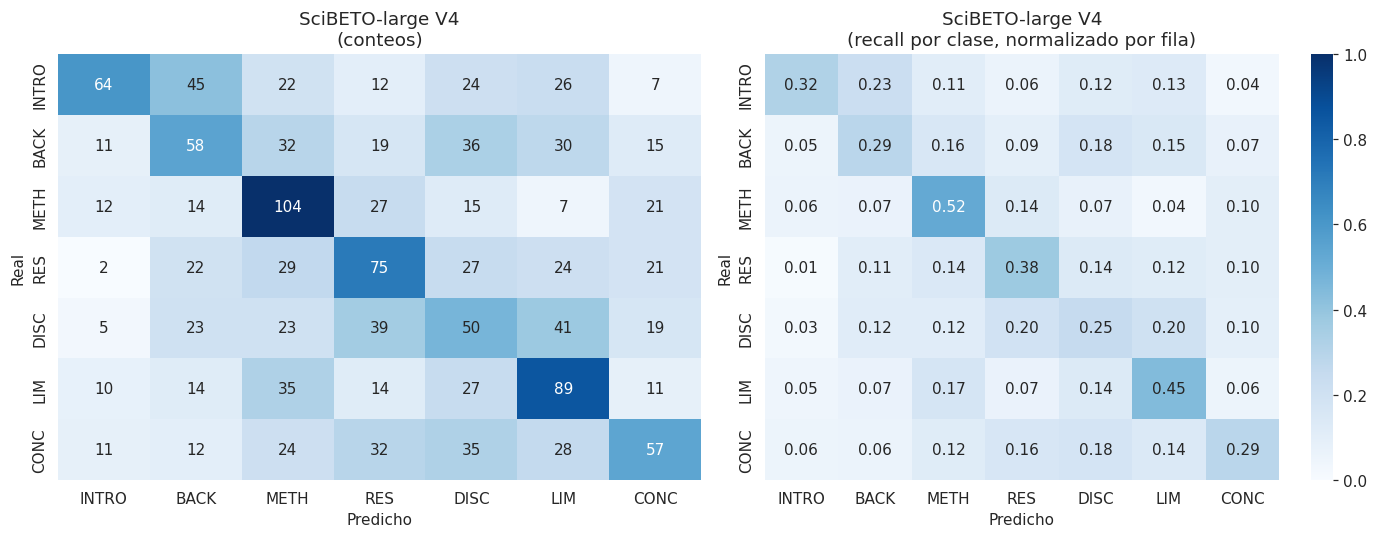

In [22]:
scibeto_test_preds = trainer.predict(tokenized['test']) # Call predict to get predictions and labels
y_true_idx = scibeto_test_preds.label_ids
y_pred_idx = np.argmax(scibeto_test_preds.predictions, axis=-1)

y_true_str = [id2label[i] for i in y_true_idx]
y_pred_str = [id2label[i] for i in y_pred_idx]

scibeto_report = full_report(
    y_true_str, y_pred_str,
    model_name=f'SciBETO-large {VERSION.upper()} (refactor + class weights + dropout 0.2 + LR 1.5e-5)',
    save_to=f'{RESULTS_DIR}/eval_scibeto_t1_{VERSION}.json',
)

plot_confusion_matrix(
    scibeto_report['confusion_matrix'], LABELS,
    title=f'SciBETO-large {VERSION.upper()}',
    save_path=f'{PLOTS_DIR}/cm_scibeto_{VERSION}.png',
)

pd.DataFrame({
    'snippet': test_df['snippet'].values,
    'actual': y_true_str, 'predicted': y_pred_str,
}).to_csv(f'{RESULTS_DIR}/preds_scibeto_t1_{VERSION}.csv', index=False)



### 6.2 Guardado del modelo SciBETO V4

In [23]:
os.makedirs(MODELS_DIR, exist_ok=True)
trainer.save_model(MODELS_DIR)
scibeto_tokenizer.save_pretrained(MODELS_DIR)

with open(f'{MODELS_DIR}/label_map.json', 'w', encoding='utf-8') as f:
    json.dump({
        'label2id': label2id, 'id2label': {str(k): v for k, v in id2label.items()},
        'task': 'T1_rhetorical_segmentation', 'n_classes': n_classes,
        'exclude_contr': EXCLUDE_CONTR, 'base_model': SCIBETO_MODEL_ID,
        'max_length': SCIBETO_MAX_TOKENS, 'version': VERSION,
    }, f, ensure_ascii=False, indent=2)

val_metrics = trainer.evaluate()
all_metrics = {
    **{f'val_{k}': float(v) if isinstance(v, (int, float, np.floating)) else str(v)
       for k, v in val_metrics.items()},
    'test_accuracy':         scibeto_report['accuracy'],
    'test_f1_macro':         scibeto_report['f1_macro'],
    'test_f1_micro':         scibeto_report['f1_micro'],
    'test_f1_per_class':     scibeto_report['f1_per_class'],
    'test_confusion_matrix': scibeto_report['confusion_matrix'],
    'test_labels_order':     scibeto_report['labels_order'],
    'training_time_minutes': scibeto_train_time / 60,
    'hyperparams': {'lr': LR, 'dropout': DROPOUT, 'epochs': EPOCHS, 'patience': PATIENCE,
                    'batch': TRAIN_BATCH, 'class_weights': class_weights.tolist()},
    'refactor': {'frontmatter_threshold': FRONTMATTER_THRESHOLD,
                 'target_words': TARGET_WORDS, 'jitter': JITTER, 'min_words': MIN_WORDS},
}
with open(f'{MODELS_DIR}/eval_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(all_metrics, f, ensure_ascii=False, indent=2)

with open(f'{MODELS_DIR}/soft_mask_keywords.json', 'w', encoding='utf-8') as f:
    json.dump({
        'keywords': SOFT_MASK_KEYWORDS, 'mask_token': '[MASK]',
        'note': 'En inferencia, aplicar apply_soft_mask antes de tokenizar.',
    }, f, ensure_ascii=False, indent=2)

shutil.make_archive(MODELS_DIR, 'zip', MODELS_DIR)
zip_size_mb = os.path.getsize(f'{MODELS_DIR}.zip') / 1024 / 1024
print(f'✅ SciBETO en: {MODELS_DIR}\n📦 ZIP: {zip_size_mb:.0f} MB')
for fname in sorted(os.listdir(MODELS_DIR)):
    size_mb = os.path.getsize(f'{MODELS_DIR}/{fname}') / 1024 / 1024
    print(f'  {fname:<35s}  {size_mb:>7.1f} MB')

wandb.finish()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ SciBETO en: /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/scibeto-t1-7c-v4
📦 ZIP: 1260 MB
  config.json                              0.0 MB
  eval_metrics.json                        0.0 MB
  label_map.json                           0.0 MB
  model.safetensors                     1355.7 MB
  soft_mask_keywords.json                  0.0 MB
  tokenizer.json                           3.5 MB
  tokenizer_config.json                    0.0 MB
  training_args.bin                        0.0 MB


eval/accuracy,▁▆███
eval/f1_macro,▁▆███
eval/f1_micro,▁▆███
eval/loss,█▃▁▂▂
eval/runtime,▄▁▄▂█
eval/samples_per_second,▅█▅▇▁
eval/steps_per_second,▅█▅▇▁
test/accuracy,▁
test/f1_macro,▁
test/f1_micro,▁
+9,...


In [24]:
# Liberar VRAM antes de cargar Llama
del trainer, model, scibeto_test_preds, tokenized
torch.cuda.empty_cache(); gc.collect()
if torch.cuda.is_available():
    free_gb = (torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1024**3
    print(f"VRAM libre: {free_gb:.1f} GB")

VRAM libre: 39.5 GB


## 7. Prompts: zero-shot y few-shot (compartidos por Llama y GPT)

En v3 evaluamos **dos variantes** para cada LLM:

- **Zero-shot (ZS)**: solo el `SYSTEM_PROMPT_ZS` con las descripciones de las 7 clases.
  Sin ejemplos.
- **Few-shot (FS-14)**: el mismo system prompt + bloque de 14 ejemplos (2 por clase).

Ambos comparten:
- Descripciones de clases idénticas
- Mismo parser tolerante (`parse_llm_label`)
- Mismas reglas: respuesta = sigla en mayúsculas, sin explicaciones


In [25]:
# ── Bloque few-shot (idéntico al v2) ──────────────────────────────────────
_FEW_SHOT_RAW = [
    ('INTRO', 'Este estudio busca evaluar el impacto de las redes neuronales en la detección de fallas en sistemas industriales.'),
    ('INTRO', 'El presente trabajo se enmarca en el contexto de la creciente demanda de soluciones automatizadas para la clasificación documental.'),
    ('BACK',  'Investigaciones previas de Smith et al. (2022) sugirieron que el litio es inestable en estas condiciones de presión.'),
    ('BACK',  'Diversos autores han abordado el problema desde el enfoque de aprendizaje supervisado, destacando los trabajos de Pérez (2019) y García (2021).'),
    ('METH',  'Se utilizó un diseño experimental de bloques al azar con tres repeticiones por tratamiento y análisis ANOVA de dos vías.'),
    ('METH',  'Para el procesamiento se aplicó un pipeline de tokenización, lematización con spaCy y vectorización TF-IDF previa al modelado.'),
    ('RES',   'La tasa de error disminuyó significativamente de 0.85 a 0.12 tras la optimización del modelo (p<0.01).'),
    ('RES',   'Se observó una correlación positiva (r=0.78) entre las variables analizadas en los 245 sujetos del estudio.'),
    ('DISC',  'Estos hallazgos sugieren que la presión atmosférica influye más de lo esperado, lo cual contradice estudios anteriores.'),
    ('DISC',  'La interpretación de estos resultados debe considerar el contexto socioeconómico de la población muestreada.'),
    ('LIM',   'Debido al tamaño reducido de la muestra, los resultados no pueden generalizarse a toda la población latinoamericana.'),
    ('LIM',   'Una restricción importante fue la imposibilidad de acceder a datos longitudinales superiores a tres años.'),
    ('CONC',  'En conclusión, el sistema propuesto es viable para implementaciones industriales a gran escala con margen de error aceptable.'),
    ('CONC',  'Finalmente, se recomienda continuar investigando el efecto a largo plazo en estudios con muestras más amplias.'),
]
_FEW_SHOT_RAW = [(lbl, txt) for (lbl, txt) in _FEW_SHOT_RAW if lbl in LABELS]

def build_few_shot_block(seed=SEED):
    rng = random.Random(seed)
    examples = list(_FEW_SHOT_RAW); rng.shuffle(examples)
    block = 'Aquí tienes ejemplos de clasificación correcta:\n'
    for lbl, txt in examples:
        block += f'\nFragmento: "{txt}"\nCategoría: {lbl}\n'
    return block

FEW_SHOT_BLOCK = build_few_shot_block(SEED)
print(f'Few-shot: {len(_FEW_SHOT_RAW)} ejemplos · {len(FEW_SHOT_BLOCK)} chars')

# ── Descripciones de clases (compartido ZS y FS) ──────────────────────────
_CAT_DESCRIPTIONS = {
    'INTRO': 'INTRO: Introducción, motivación, objetivos del estudio.',
    'BACK':  'BACK: Antecedentes, trabajos previos, estado del arte.',
    'METH':  'METH: Metodología, diseño experimental, materiales, procedimientos.',
    'RES':   'RES: Resultados obtenidos empíricamente (sin interpretación).',
    'DISC':  'DISC: Discusión, interpretación de resultados, implicaciones.',
    'CONTR': 'CONTR: Contribuciones científicas o aportes originales.',
    'LIM':   'LIM: Limitaciones del estudio, restricciones, sesgos.',
    'CONC':  'CONC: Conclusiones y trabajo futuro.',
}
_cats_block = '\n'.join(f'- {_CAT_DESCRIPTIONS[l]}' for l in LABELS)

# ── SYSTEM_PROMPT_ZS: zero-shot, sin ejemplos ────────────────────────────
SYSTEM_PROMPT_ZS = (
    f'Eres un asistente experto en analizar artículos científicos en español.\n'
    f'Tu tarea es clasificar el fragmento de texto en EXACTAMENTE UNA de estas '
    f'{n_classes} categorías:\n{_cats_block}\n\n'
    f'Nota: El texto contiene palabras reemplazadas por "[MASK]". Deduce la categoría '
    f'basándote en la semántica del resto del texto.\n\n'
    f'Reglas: Responde ÚNICAMENTE con la sigla (ejemplo: INTRO, METH, DISC). '
    f'Sin explicaciones.'
)

# ── SYSTEM_PROMPT_FS: few-shot, igual al ZS + 14 ejemplos ────────────────
SYSTEM_PROMPT_FS = SYSTEM_PROMPT_ZS + '\n\n' + FEW_SHOT_BLOCK

# Compat con código v2 que usa "SYSTEM_PROMPT" sin sufijo
SYSTEM_PROMPT = SYSTEM_PROMPT_FS

print(f'\nSYSTEM_PROMPT_ZS: {len(SYSTEM_PROMPT_ZS)} chars')
print(f'SYSTEM_PROMPT_FS: {len(SYSTEM_PROMPT_FS)} chars (= ZS + {len(SYSTEM_PROMPT_FS)-len(SYSTEM_PROMPT_ZS)} chars del few-shot)')


Few-shot: 14 ejemplos · 2121 chars

SYSTEM_PROMPT_ZS: 785 chars
SYSTEM_PROMPT_FS: 2908 chars (= ZS + 2123 chars del few-shot)


## 8. Llama 3.1 8B — zero-shot y few-shot

Carga el modelo una sola vez (4-bit) y corre **dos evaluaciones**: ZS y FS-14.
Usamos `wandb` con runs separados para que las métricas queden trazables.


In [26]:
from google.colab import userdata
os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')

In [27]:
LLAMA_MODEL_ID = 'meta-llama/Llama-3.1-8B-Instruct'
LLAMA_MAX_NEW_TOKENS = 8
LLAMA_TEMPERATURE = 0.0

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type='nf4', bnb_4bit_use_double_quant=True,
)
llama_tokenizer = AutoTokenizer.from_pretrained(LLAMA_MODEL_ID)
llama_model = AutoModelForCausalLM.from_pretrained(
    LLAMA_MODEL_ID, quantization_config=bnb_config, device_map='auto',
)
llama_model.eval()
print(f'✅ Llama cargado · {sum(p.numel() for p in llama_model.parameters())/1e9:.1f}B params')

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

✅ Llama cargado · 4.5B params


In [28]:
# Función parametrizada: corre inferencia Llama con cualquier system_prompt.
# Devuelve (predictions, raw_responses, elapsed_sec, truncation_count).

LLAMA_MAX_NEW_TOKENS = 8
LLAMA_TEMPERATURE = 0.0
LLAMA_MAX_INPUT = 7000  # tokens

def run_llama_evaluation(system_prompt: str, variant_name: str):
    """Ejecuta Llama sobre test_df con el system_prompt dado."""
    def build_prompt(snippet: str) -> str:
        messages = [
            {'role': 'system', 'content': system_prompt},
            {'role': 'user',   'content': f'Fragmento: "{snippet}"\nCategoría:'},
        ]
        return llama_tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True,
        )

    print(f"\n{'='*60}\nLlama 3.1 8B — {variant_name}\n{'='*60}")
    print(f"system_prompt: {len(system_prompt)} chars")

    predictions, raw_responses = [], []
    truncation_count = 0
    t0 = time.time()

    for i, row in test_df.iterrows():
        prompt = build_prompt(row['neutralized_snippet'])
        inputs = llama_tokenizer(prompt, return_tensors='pt', truncation=False)
        if inputs['input_ids'].shape[1] > LLAMA_MAX_INPUT:
            inputs = llama_tokenizer(prompt, return_tensors='pt',
                                      truncation=True, max_length=LLAMA_MAX_INPUT)
            truncation_count += 1
        inputs = {k: v.to(llama_model.device) for k, v in inputs.items()}
        with torch.no_grad():
            out = llama_model.generate(
                **inputs, max_new_tokens=LLAMA_MAX_NEW_TOKENS,
                do_sample=False, temperature=LLAMA_TEMPERATURE,
                pad_token_id=llama_tokenizer.eos_token_id,
            )
        response = llama_tokenizer.decode(
            out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True,
        )
        predictions.append(parse_llm_label(response))
        raw_responses.append(response)

        if (i + 1) % 200 == 0:
            print(f"  {i+1}/{len(test_df)} · {time.time()-t0:.0f}s")

    elapsed = time.time() - t0
    print(f"\n[OK] {variant_name}: {elapsed/60:.1f} min · {truncation_count} truncados")
    return predictions, raw_responses, elapsed, truncation_count


### 8.1 Llama 3.1 8B — zero-shot (ZS)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



Llama 3.1 8B — ZERO-SHOT
system_prompt: 785 chars
  200/1400 · 55s
  400/1400 · 110s
  600/1400 · 162s
  800/1400 · 215s
  1000/1400 · 265s
  1200/1400 · 324s
  1400/1400 · 384s

[OK] ZERO-SHOT: 6.4 min · 0 truncados

Llama 3.1 8B V4 — Zero-Shot
Accuracy: 0.2786 | Macro F1: 0.2338 | Micro F1: 0.2788
UNKNOWN: 2/1400

Classification report:
              precision    recall  f1-score   support

       INTRO      0.244     0.485     0.324       200
        BACK      0.238     0.627     0.345       201
        METH      0.377     0.500     0.430       200
         RES      0.254     0.075     0.116       200
        DISC      0.180     0.090     0.120       200
         LIM      0.719     0.115     0.198       200
        CONC      0.786     0.055     0.103       199

   micro avg      0.279     0.279     0.279      1400
   macro avg      0.400     0.278     0.234      1400
weighted avg      0.399     0.279     0.234      1400

Matriz de confusión (filas=real, cols=predicho):
       INTRO

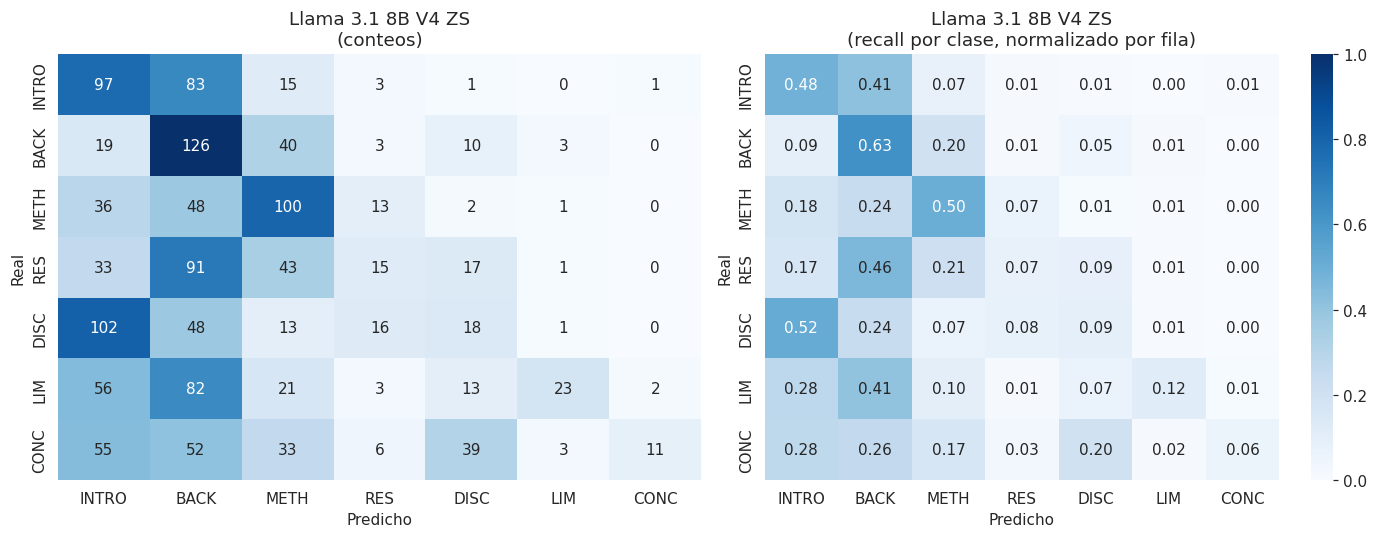

accuracy,▁
f1_macro,▁
f1_micro,▁
inference_time_min,▁
truncation_count,▁
unknown,▁
accuracy,0.27857
f1_macro,0.23381
f1_micro,0.27877
inference_time_min,6.39306
truncation_count,0


In [29]:
llama_zs_run = wandb.init(
    project="maia-flag-document-analysis",
    entity="natamoncada10-universidad-de-los-andes",
    name="task1_llama_zs_edwin_v3",
    tags=["llm", "llama", "zero-shot"],
    config={
        "model": LLAMA_MODEL_ID, "variant": "zero-shot",
        "prompt_chars": len(SYSTEM_PROMPT_ZS),
        "max_new_tokens": LLAMA_MAX_NEW_TOKENS,
        "temperature": LLAMA_TEMPERATURE,
    },
)

llama_zs_preds, llama_zs_raws, llama_zs_time, llama_zs_trunc = run_llama_evaluation(
    SYSTEM_PROMPT_ZS, "ZERO-SHOT"
)

llama_zs_actuals = test_df['category'].tolist()
llama_zs_report = full_report(
    llama_zs_actuals, llama_zs_preds,
    f'Llama 3.1 8B {VERSION.upper()} — Zero-Shot',
    save_to=f'{RESULTS_DIR}/T1_llama_zs_{VERSION}.json',
)
wandb.log({
    'accuracy': llama_zs_report['accuracy'],
    'f1_macro': llama_zs_report['f1_macro'],
    'f1_micro': llama_zs_report['f1_micro'],
    'unknown': llama_zs_report['unknown_predictions'],
    'inference_time_min': llama_zs_time / 60,
    'truncation_count': llama_zs_trunc,
})
plot_confusion_matrix(
    llama_zs_report['confusion_matrix'], LABELS,
    f'Llama 3.1 8B {VERSION.upper()} ZS',
    save_path=f'{RESULTS_DIR}/T1_llama_zs_cm_{VERSION}.png',
)
wandb.finish()


### 8.2 Llama 3.1 8B — few-shot (FS-14)


Llama 3.1 8B — FEW-SHOT k=14
system_prompt: 2908 chars
  200/1400 · 64s
  400/1400 · 131s
  600/1400 · 187s
  800/1400 · 243s
  1000/1400 · 303s
  1200/1400 · 371s
  1400/1400 · 440s

[OK] FEW-SHOT k=14: 7.3 min · 0 truncados

Llama 3.1 8B V4 — Few-Shot k=14
Accuracy: 0.3550 | Macro F1: 0.3223 | Micro F1: 0.3558
UNKNOWN: 6/1400

Classification report:
              precision    recall  f1-score   support

       INTRO      0.399     0.615     0.484       200
        BACK      0.250     0.756     0.376       201
        METH      0.522     0.480     0.500       200
         RES      0.400     0.140     0.207       200
        DISC      0.325     0.250     0.282       200
         LIM      0.682     0.150     0.246       200
        CONC      0.692     0.090     0.160       199

   micro avg      0.357     0.355     0.356      1400
   macro avg      0.467     0.355     0.322      1400
weighted avg      0.467     0.355     0.322      1400

Matriz de confusión (filas=real, cols=predicho):

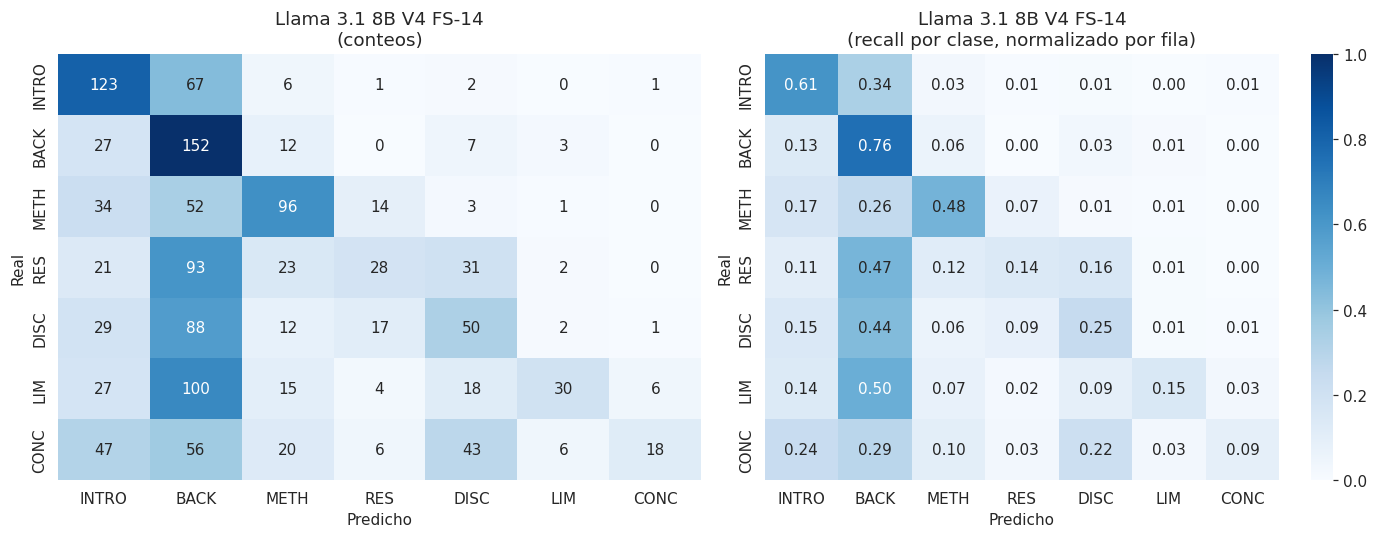

accuracy,▁
f1_macro,▁
f1_micro,▁
inference_time_min,▁
truncation_count,▁
unknown,▁
accuracy,0.355
f1_macro,0.32226
f1_micro,0.35576
inference_time_min,7.34083
truncation_count,0



[OK] Llama liberado de VRAM.


In [30]:
llama_fs_run = wandb.init(
    project="maia-flag-document-analysis",
    entity="natamoncada10-universidad-de-los-andes",
    name="task1_llama_fs_edwin_v3",
    tags=["llm", "llama", "few-shot", "k=14"],
    config={
        "model": LLAMA_MODEL_ID, "variant": "few-shot",
        "n_few_shot": len(_FEW_SHOT_RAW),
        "prompt_chars": len(SYSTEM_PROMPT_FS),
        "max_new_tokens": LLAMA_MAX_NEW_TOKENS,
        "temperature": LLAMA_TEMPERATURE,
    },
)

llama_fs_preds, llama_fs_raws, llama_fs_time, llama_fs_trunc = run_llama_evaluation(
    SYSTEM_PROMPT_FS, "FEW-SHOT k=14"
)

llama_fs_actuals = test_df['category'].tolist()
llama_fs_report = full_report(
    llama_fs_actuals, llama_fs_preds,
    f'Llama 3.1 8B {VERSION.upper()} — Few-Shot k=14',
    save_to=f'{RESULTS_DIR}/T1_llama_fs_{VERSION}.json',
)
wandb.log({
    'accuracy': llama_fs_report['accuracy'],
    'f1_macro': llama_fs_report['f1_macro'],
    'f1_micro': llama_fs_report['f1_micro'],
    'unknown': llama_fs_report['unknown_predictions'],
    'inference_time_min': llama_fs_time / 60,
    'truncation_count': llama_fs_trunc,
})
plot_confusion_matrix(
    llama_fs_report['confusion_matrix'], LABELS,
    f'Llama 3.1 8B {VERSION.upper()} FS-14',
    save_path=f'{RESULTS_DIR}/T1_llama_fs_cm_{VERSION}.png',
)
wandb.finish()

# Liberar memoria del modelo Llama
del llama_model
gc.collect()
torch.cuda.empty_cache()
print("\n[OK] Llama liberado de VRAM.")


## 9. GPT-4o-mini — zero-shot y few-shot

API de OpenAI con JSON mode + retry exponencial + concurrency=8.
Como con Llama, dos runs separados en W&B.


In [32]:
from openai import AsyncOpenAI, RateLimitError, APIError, APITimeoutError
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type

OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
client = AsyncOpenAI(api_key=OPENAI_API_KEY)

GPT_MODEL = 'gpt-4o-mini'
GPT_TEMPERATURE = 0.0
GPT_MAX_TOKENS = 16
CONCURRENCY = 8
MAX_RETRIES = 5

# Costos GPT-4o-mini (USD/M tokens, snapshot mayo 2026)
GPT_COST_INPUT_PER_M = 0.150
GPT_COST_OUTPUT_PER_M = 0.600

async def run_gpt_evaluation(system_prompt: str, variant_name: str):
    """Ejecuta GPT sobre test_df con el system_prompt dado.
    Devuelve (preds, raws, elapsed, errores_irrecuperables, costo_estimado_usd).
    """

    # JSON mode requiere mencionar "JSON" en el prompt — lo agregamos
    sp_with_json = system_prompt + '\n\nResponde en formato JSON: {"category": "SIGLA"}'

    @retry(
        stop=stop_after_attempt(MAX_RETRIES),
        wait=wait_exponential(multiplier=2, min=2, max=60),
        retry=retry_if_exception_type((RateLimitError, APIError, APITimeoutError)),
        reraise=True,
    )
    async def classify_one(snippet: str):
        resp = await client.chat.completions.create(
            model=GPT_MODEL,
            messages=[
                {'role': 'system', 'content': sp_with_json},
                {'role': 'user',   'content': f'Fragmento: "{snippet}"'},
            ],
            temperature=GPT_TEMPERATURE, max_tokens=GPT_MAX_TOKENS,
            response_format={'type': 'json_object'},
        )
        raw = resp.choices[0].message.content
        usage = resp.usage
        return parse_llm_label(raw), raw, usage.prompt_tokens, usage.completion_tokens

    async def classify_batch(snippets):
        sem = asyncio.Semaphore(CONCURRENCY)
        async def bounded(s):
            async with sem:
                try:
                    return await classify_one(s)
                except Exception as e:
                    return 'UNKNOWN', f'ERROR: {str(e)[:200]}', 0, 0
        return await asyncio.gather(*[bounded(s) for s in snippets])

    print(f"\n{'='*60}\nGPT-4o-mini — {variant_name}\n{'='*60}")
    print(f"system_prompt: {len(sp_with_json)} chars")

    snippets = test_df['neutralized_snippet'].tolist()
    t0 = time.time()
    total_in_tokens, total_out_tokens = 0, 0

    async def run_all():
        results = []
        chunk = 200
        for i in range(0, len(snippets), chunk):
            batch = snippets[i:i+chunk]
            batch_results = await classify_batch(batch)
            results.extend(batch_results)
            elapsed = time.time() - t0
            rate = (i + len(batch)) / elapsed if elapsed > 0 else 0
            print(f"  {i+len(batch)}/{len(snippets)} · {elapsed:.0f}s · {rate:.1f} req/s")
        return results

    results = await run_all()
    elapsed = time.time() - t0

    preds, raws, errors = [], [], []
    for i, (pred, raw, in_tok, out_tok) in enumerate(results):
        preds.append(pred); raws.append(raw)
        total_in_tokens += in_tok; total_out_tokens += out_tok
        if raw.startswith('ERROR'):
            errors.append((i, raw))

    cost = (total_in_tokens / 1e6 * GPT_COST_INPUT_PER_M +
            total_out_tokens / 1e6 * GPT_COST_OUTPUT_PER_M)

    print(f"\n[OK] {variant_name}: {elapsed/60:.1f} min · "
          f"tokens in={total_in_tokens:,} out={total_out_tokens:,} · "
          f"costo USD ${cost:.4f}")
    if errors:
        print(f"  [!] {len(errors)} errores tras {MAX_RETRIES} reintentos")
    return preds, raws, elapsed, errors, cost

### 9.1 GPT-4o-mini — zero-shot (ZS)


GPT-4o-mini — ZERO-SHOT
system_prompt: 834 chars
  200/1400 · 26s · 7.8 req/s
  400/1400 · 50s · 8.0 req/s
  600/1400 · 73s · 8.3 req/s
  800/1400 · 98s · 8.2 req/s
  1000/1400 · 120s · 8.4 req/s
  1200/1400 · 145s · 8.3 req/s
  1400/1400 · 172s · 8.1 req/s

[OK] ZERO-SHOT: 2.9 min · tokens in=899,647 out=8,722 · costo USD $0.1402

GPT-4o-mini V4 — Zero-Shot
Accuracy: 0.4714 | Macro F1: 0.4471 | Micro F1: 0.4714
UNKNOWN: 0/1400

Classification report:
              precision    recall  f1-score   support

       INTRO      0.477     0.710     0.570       200
        BACK      0.411     0.736     0.528       201
        METH      0.612     0.695     0.651       200
         RES      0.398     0.380     0.389       200
        DISC      0.319     0.365     0.340       200
         LIM      0.859     0.275     0.417       200
        CONC      0.871     0.136     0.235       199

    accuracy                          0.471      1400
   macro avg      0.564     0.471     0.447      1400
w

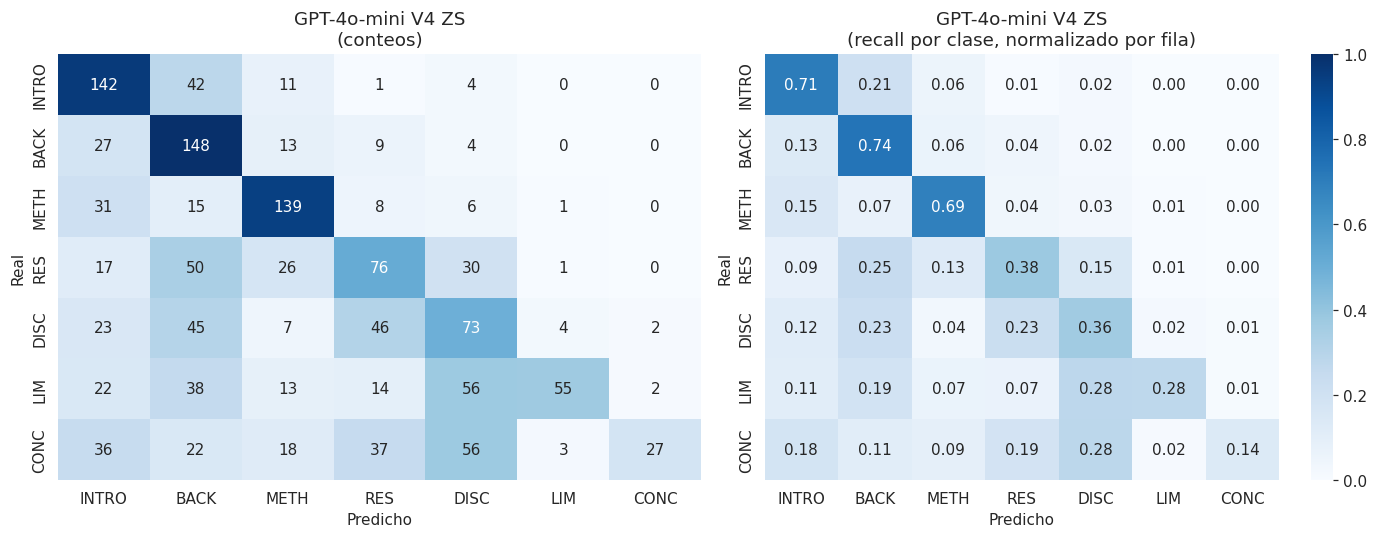

accuracy,▁
cost_usd,▁
errors,▁
f1_macro,▁
f1_micro,▁
inference_time_min,▁
unknown,▁
accuracy,0.47143
cost_usd,0.14018
errors,0
f1_macro,0.44707


In [35]:
gpt_zs_run = wandb.init(
    project="maia-flag-document-analysis",
    entity="natamoncada10-universidad-de-los-andes",
    name="task1_gpt_zs_edwin_v3",
    tags=["llm", "gpt", "zero-shot", "api"],
    config={
        "model": GPT_MODEL, "variant": "zero-shot",
        "prompt_chars": len(SYSTEM_PROMPT_ZS),
        "json_mode": True, "concurrency": CONCURRENCY,
    },
)

gpt_zs_preds, gpt_zs_raws, gpt_zs_time, gpt_zs_errors, gpt_zs_cost = await run_gpt_evaluation(
    SYSTEM_PROMPT_ZS, "ZERO-SHOT"
)

gpt_zs_actuals = test_df['category'].tolist()
gpt_zs_report = full_report(
    gpt_zs_actuals, gpt_zs_preds,
    f'GPT-4o-mini {VERSION.upper()} — Zero-Shot',
    save_to=f'{RESULTS_DIR}/T1_gpt_zs_{VERSION}.json',
)
wandb.log({
    'accuracy': gpt_zs_report['accuracy'],
    'f1_macro': gpt_zs_report['f1_macro'],
    'f1_micro': gpt_zs_report['f1_micro'],
    'unknown': gpt_zs_report['unknown_predictions'],
    'inference_time_min': gpt_zs_time / 60,
    'cost_usd': gpt_zs_cost,
    'errors': len(gpt_zs_errors),
})
plot_confusion_matrix(
    gpt_zs_report['confusion_matrix'], LABELS,
    f'GPT-4o-mini {VERSION.upper()} ZS',
    save_path=f'{RESULTS_DIR}/T1_gpt_zs_cm_{VERSION}.png',
)
wandb.finish()


### 9.2 GPT-4o-mini — few-shot (FS-14)


GPT-4o-mini — FEW-SHOT k=14
system_prompt: 2957 chars
  200/1400 · 33s · 6.1 req/s
  400/1400 · 62s · 6.4 req/s
  600/1400 · 96s · 6.2 req/s
  800/1400 · 135s · 5.9 req/s
  1000/1400 · 177s · 5.6 req/s
  1200/1400 · 223s · 5.4 req/s
  1400/1400 · 256s · 5.5 req/s

[OK] FEW-SHOT k=14: 4.3 min · tokens in=1,578,647 out=8,659 · costo USD $0.2420

GPT-4o-mini V4 — Few-Shot k=14
Accuracy: 0.4457 | Macro F1: 0.4144 | Micro F1: 0.4457
UNKNOWN: 0/1400

Classification report:
              precision    recall  f1-score   support

       INTRO      0.411     0.735     0.527       200
        BACK      0.423     0.741     0.539       201
        METH      0.635     0.600     0.617       200
         RES      0.410     0.320     0.360       200
        DISC      0.305     0.420     0.354       200
         LIM      0.889     0.200     0.327       200
        CONC      0.800     0.101     0.179       199

    accuracy                          0.446      1400
   macro avg      0.553     0.445     0

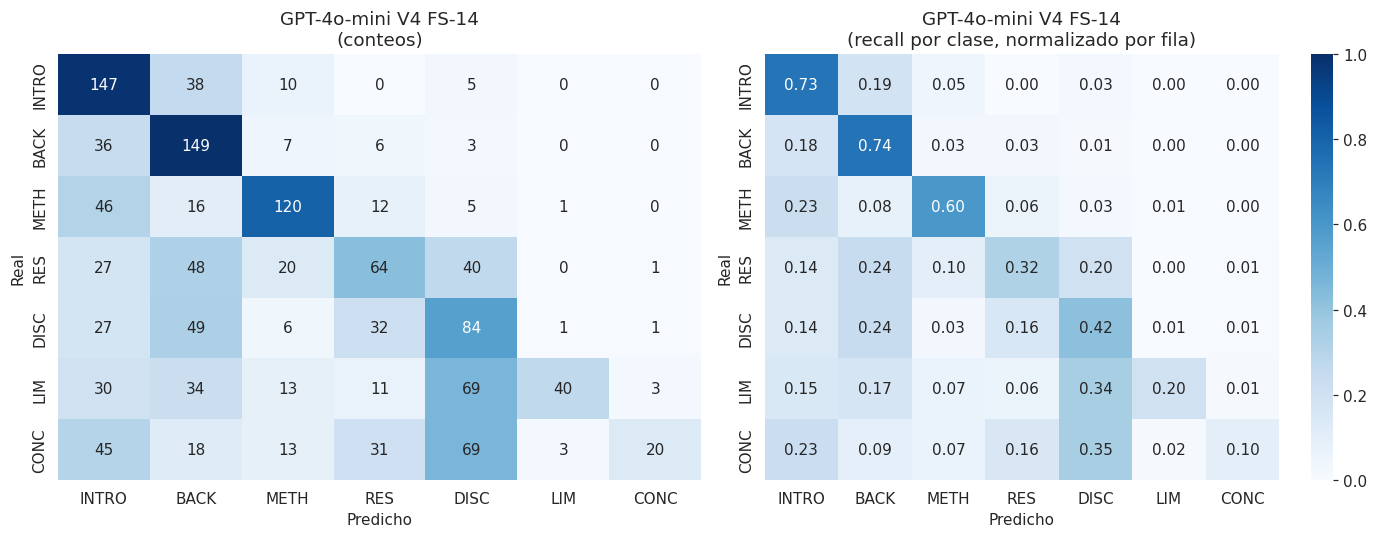

accuracy,▁
cost_usd,▁
errors,▁
f1_macro,▁
f1_micro,▁
inference_time_min,▁
unknown,▁
accuracy,0.44571
cost_usd,0.24199
errors,0
f1_macro,0.41444


In [37]:
gpt_fs_run = wandb.init(
    project="maia-flag-document-analysis",
    entity="natamoncada10-universidad-de-los-andes",
    name="task1_gpt_fs_edwin_v3",
    tags=["llm", "gpt", "few-shot", "k=14", "api"],
    config={
        "model": GPT_MODEL, "variant": "few-shot",
        "n_few_shot": len(_FEW_SHOT_RAW),
        "prompt_chars": len(SYSTEM_PROMPT_FS),
        "json_mode": True, "concurrency": CONCURRENCY,
    },
)

gpt_fs_preds, gpt_fs_raws, gpt_fs_time, gpt_fs_errors, gpt_fs_cost = await run_gpt_evaluation(
    SYSTEM_PROMPT_FS, "FEW-SHOT k=14"
)

gpt_fs_actuals = test_df['category'].tolist()
gpt_fs_report = full_report(
    gpt_fs_actuals, gpt_fs_preds,
    f'GPT-4o-mini {VERSION.upper()} — Few-Shot k=14',
    save_to=f'{RESULTS_DIR}/T1_gpt_fs_{VERSION}.json',
)
wandb.log({
    'accuracy': gpt_fs_report['accuracy'],
    'f1_macro': gpt_fs_report['f1_macro'],
    'f1_micro': gpt_fs_report['f1_micro'],
    'unknown': gpt_fs_report['unknown_predictions'],
    'inference_time_min': gpt_fs_time / 60,
    'cost_usd': gpt_fs_cost,
    'errors': len(gpt_fs_errors),
})
plot_confusion_matrix(
    gpt_fs_report['confusion_matrix'], LABELS,
    f'GPT-4o-mini {VERSION.upper()} FS-14',
    save_path=f'{RESULTS_DIR}/T1_gpt_fs_cm_{VERSION}.png',
)
wandb.finish()


## 10. Comparación final — los 5 modelos

Tabla unificada con SciBETO fine-tuned + 4 variantes de LLM (Llama ZS/FS, GPT ZS/FS).

**Hipótesis a verificar:**
- ¿El few-shot mejora a Llama? ¿En cuánto?
- ¿El few-shot mejora a GPT? ¿En cuánto?
- ¿Algún LLM (con o sin few-shot) supera a SciBETO fine-tuned?
- ¿Cuál es la diferencia de costo de inferencia entre las 4 variantes LLM?


In [38]:
comparison = pd.DataFrame([
    {
        'Modelo': f'SciBETO-large {VERSION.upper()} (FT 4ep, class weights, refactor)',
        'Variante': '—',
        'Accuracy': scibeto_report['accuracy'],
        'F1 Macro': scibeto_report['f1_macro'],
        'F1 Micro': scibeto_report['f1_micro'],
        'UNKNOWN': scibeto_report['unknown_predictions'],
        'Tiempo (min)': round(scibeto_train_time / 60, 1),
        'Costo USD': 0.0,
        'Notas': f'{EPOCHS}ep, drop={DROPOUT}, lr={LR}',
    },
    {
        'Modelo': 'Llama 3.1 8B',
        'Variante': 'Zero-shot',
        'Accuracy': llama_zs_report['accuracy'],
        'F1 Macro': llama_zs_report['f1_macro'],
        'F1 Micro': llama_zs_report['f1_micro'],
        'UNKNOWN': llama_zs_report['unknown_predictions'],
        'Tiempo (min)': round(llama_zs_time / 60, 1),
        'Costo USD': 0.0,
        'Notas': f'4-bit, trunc={llama_zs_trunc}',
    },
    {
        'Modelo': 'Llama 3.1 8B',
        'Variante': 'Few-shot k=14',
        'Accuracy': llama_fs_report['accuracy'],
        'F1 Macro': llama_fs_report['f1_macro'],
        'F1 Micro': llama_fs_report['f1_micro'],
        'UNKNOWN': llama_fs_report['unknown_predictions'],
        'Tiempo (min)': round(llama_fs_time / 60, 1),
        'Costo USD': 0.0,
        'Notas': f'4-bit, parser tolerante, trunc={llama_fs_trunc}',
    },
    {
        'Modelo': f'{GPT_MODEL}',
        'Variante': 'Zero-shot',
        'Accuracy': gpt_zs_report['accuracy'],
        'F1 Macro': gpt_zs_report['f1_macro'],
        'F1 Micro': gpt_zs_report['f1_micro'],
        'UNKNOWN': gpt_zs_report['unknown_predictions'],
        'Tiempo (min)': round(gpt_zs_time / 60, 1),
        'Costo USD': round(gpt_zs_cost, 4),
        'Notas': f'API · JSON mode · conc={CONCURRENCY}',
    },
    {
        'Modelo': f'{GPT_MODEL}',
        'Variante': 'Few-shot k=14',
        'Accuracy': gpt_fs_report['accuracy'],
        'F1 Macro': gpt_fs_report['f1_macro'],
        'F1 Micro': gpt_fs_report['f1_micro'],
        'UNKNOWN': gpt_fs_report['unknown_predictions'],
        'Tiempo (min)': round(gpt_fs_time / 60, 1),
        'Costo USD': round(gpt_fs_cost, 4),
        'Notas': f'API · JSON mode · conc={CONCURRENCY}',
    },
])

print(f'\n=== Comparación · Tarea 1 ({VERSION.upper()}) — 5 modelos ===\n')
print(comparison.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
comparison.to_csv(f'{RESULTS_DIR}/T1_comparison_5models_{VERSION}.csv', index=False)

# ── Análisis del impacto del few-shot ──────────────────────────────────────
print(f'\n=== Impacto del few-shot (delta vs zero-shot) ===\n')
print(f"Llama: ZS F1 macro = {llama_zs_report['f1_macro']:.4f}")
print(f"       FS F1 macro = {llama_fs_report['f1_macro']:.4f}")
delta_llama = llama_fs_report['f1_macro'] - llama_zs_report['f1_macro']
print(f"       Δ = {delta_llama:+.4f}  ({'mejora' if delta_llama > 0 else 'degrada'})")

print(f"\nGPT:   ZS F1 macro = {gpt_zs_report['f1_macro']:.4f}")
print(f"       FS F1 macro = {gpt_fs_report['f1_macro']:.4f}")
delta_gpt = gpt_fs_report['f1_macro'] - gpt_zs_report['f1_macro']
print(f"       Δ = {delta_gpt:+.4f}  ({'mejora' if delta_gpt > 0 else 'degrada'})")



=== Comparación · Tarea 1 (V4) — 5 modelos ===

                                            Modelo      Variante  Accuracy  F1 Macro  F1 Micro  UNKNOWN  Tiempo (min)  Costo USD                            Notas
SciBETO-large V4 (FT 4ep, class weights, refactor)             —    0.3550    0.3535    0.3550        0        8.2000     0.0000        4ep, drop=0.2, lr=1.5e-05
                                      Llama 3.1 8B     Zero-shot    0.2786    0.2338    0.2788        2        6.4000     0.0000                   4-bit, trunc=0
                                      Llama 3.1 8B Few-shot k=14    0.3550    0.3223    0.3558        6        7.3000     0.0000 4-bit, parser tolerante, trunc=0
                                       gpt-4o-mini     Zero-shot    0.4714    0.4471    0.4714        0        2.9000     0.1402         API · JSON mode · conc=8
                                       gpt-4o-mini Few-shot k=14    0.4457    0.4144    0.4457        0        4.3000     0.2420         API 

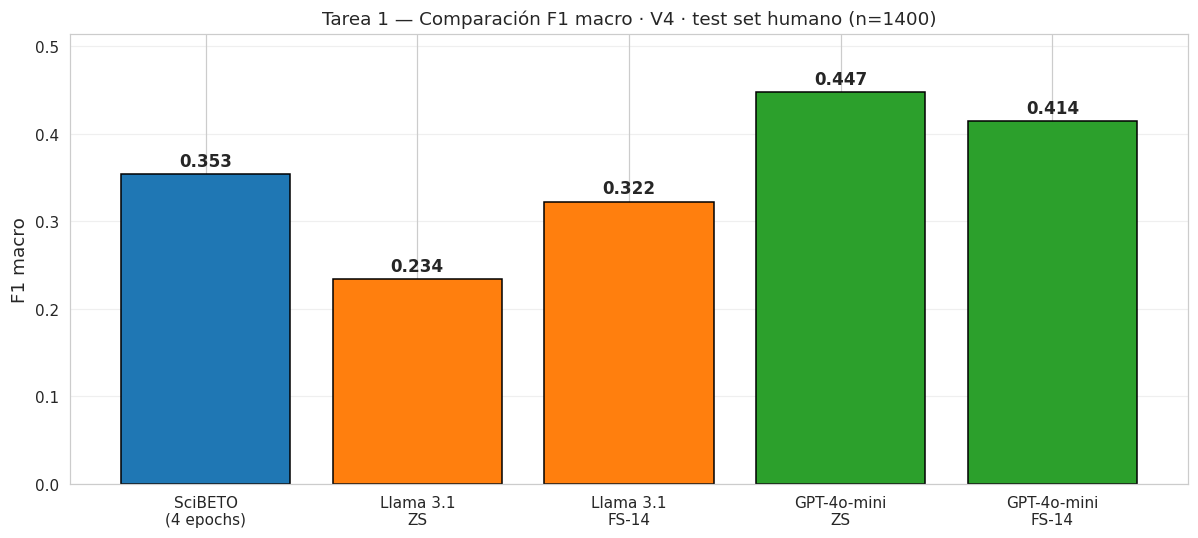

In [39]:
# Bar chart — F1 macro de los 5 modelos
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5))
labels = ['SciBETO\n(4 epochs)',
          'Llama 3.1\nZS', 'Llama 3.1\nFS-14',
          'GPT-4o-mini\nZS', 'GPT-4o-mini\nFS-14']
f1_values = [scibeto_report['f1_macro'],
             llama_zs_report['f1_macro'], llama_fs_report['f1_macro'],
             gpt_zs_report['f1_macro'], gpt_fs_report['f1_macro']]
colors = ['#1f77b4', '#ff7f0e', '#ff7f0e', '#2ca02c', '#2ca02c']

bars = ax.bar(labels, f1_values, color=colors, edgecolor='black')
for bar, val in zip(bars, f1_values):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('F1 macro', fontsize=12)
ax.set_title(f'Tarea 1 — Comparación F1 macro · {VERSION.upper()} · '
             f'test set humano (n={len(test_df)})', fontsize=12)
ax.set_ylim(0, max(f1_values) * 1.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/T1_f1_comparison_{VERSION}.png', dpi=120, bbox_inches='tight')
plt.show()


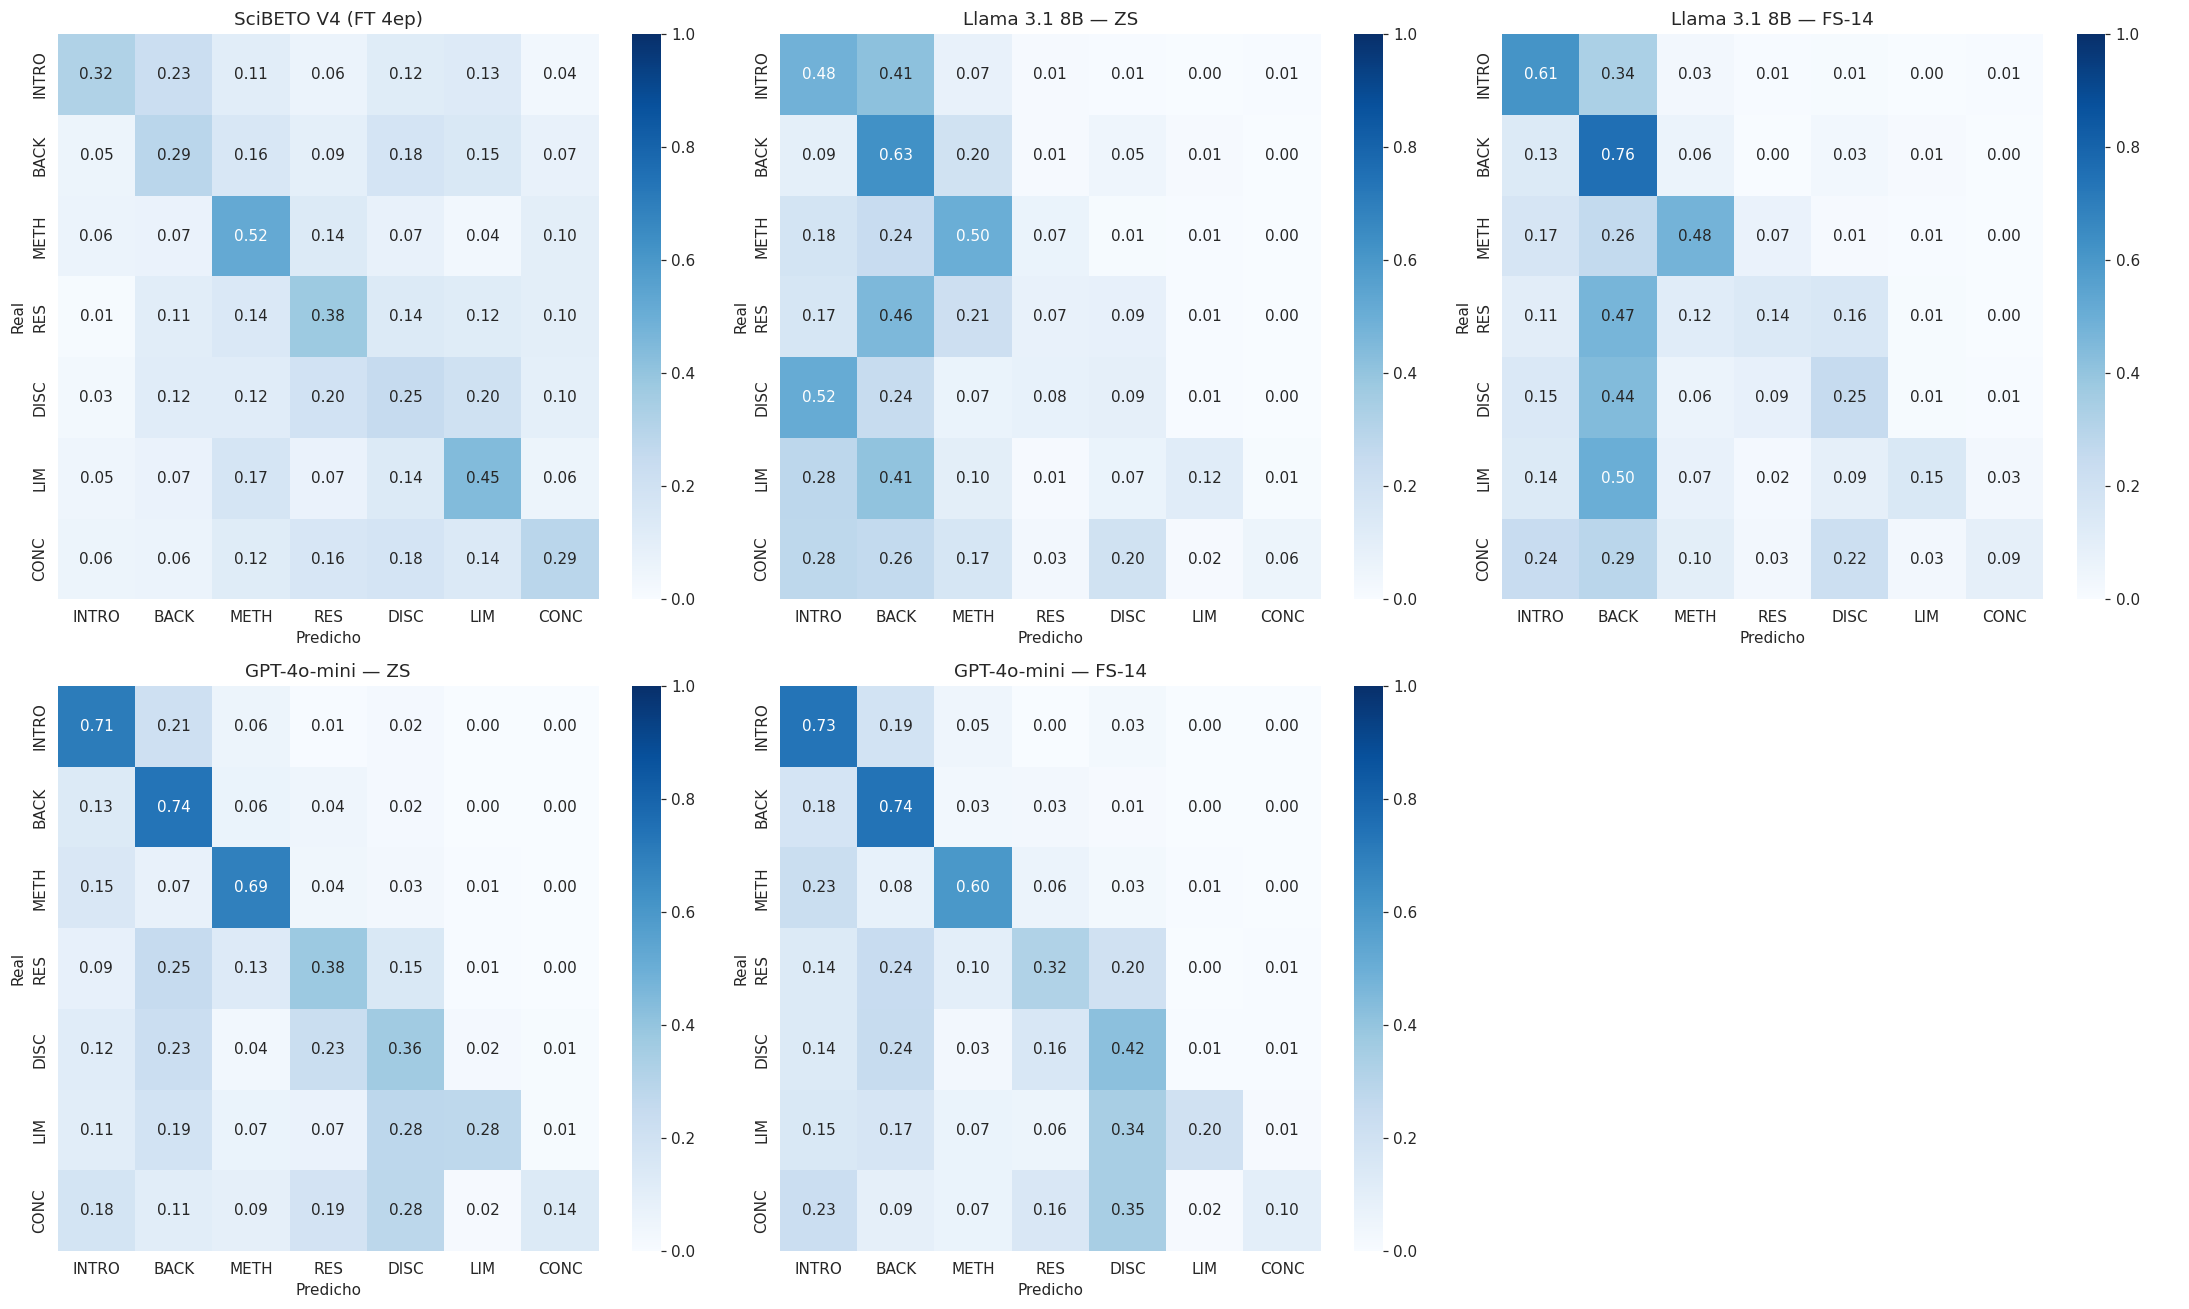


[OK] Comparación final guardada en /content/drive/MyDrive/UNIANDES/MAESTRIA_INTELIGENCIA_ARTICIFIAL/SEM_4.2_Proyecto_Despliegue_Soluciones/colab/


In [40]:
# Matrices de confusión — los 5 modelos lado a lado (recall normalizado por fila)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

cms_and_titles = [
    (scibeto_report['confusion_matrix'], f'SciBETO {VERSION.upper()} (FT 4ep)'),
    (llama_zs_report['confusion_matrix'], 'Llama 3.1 8B — ZS'),
    (llama_fs_report['confusion_matrix'], 'Llama 3.1 8B — FS-14'),
    (gpt_zs_report['confusion_matrix'], 'GPT-4o-mini — ZS'),
    (gpt_fs_report['confusion_matrix'], 'GPT-4o-mini — FS-14'),
]

for ax, (cm, title) in zip(axes.flatten(), cms_and_titles):
    cm = np.asarray(cm)
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=LABELS, yticklabels=LABELS,
                ax=ax, cbar=True, vmin=0, vmax=1)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    ax.set_title(title)

# Ocultar el 6to subplot que sobra
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/T1_confusion_matrices_5models_{VERSION}.png',
            dpi=120, bbox_inches='tight')
plt.show()
print(f'\n[OK] Comparación final guardada en {RESULTS_DIR}/')


### 10.1 F1 por clase — ¿qué categoría se beneficia más del few-shot?


=== F1 por clase ===

                   INTRO  BACK  METH   RES  DISC   LIM  CONC
SciBETO (4ep)      0.406 0.298 0.443 0.359 0.242 0.400 0.326
Llama ZS           0.324 0.345 0.430 0.116 0.120 0.198 0.103
Llama FS-14        0.484 0.376 0.500 0.207 0.282 0.246 0.160
GPT-4o-mini ZS     0.570 0.528 0.651 0.389 0.340 0.417 0.235
GPT-4o-mini FS-14  0.527 0.539 0.617 0.360 0.354 0.327 0.179


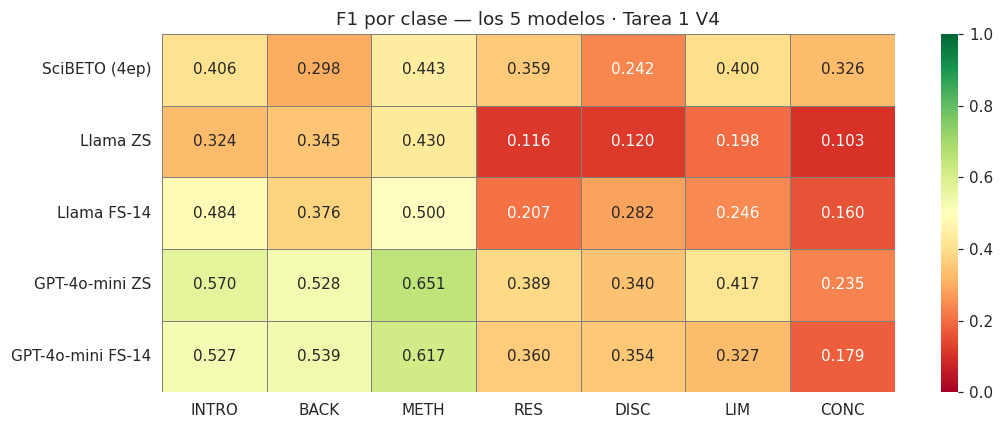

In [41]:
# Heatmap de F1 por clase para los 5 modelos
per_class_df = pd.DataFrame({
    'SciBETO (4ep)':       [scibeto_report['f1_per_class'][l] for l in LABELS],
    'Llama ZS':            [llama_zs_report['f1_per_class'][l] for l in LABELS],
    'Llama FS-14':         [llama_fs_report['f1_per_class'][l] for l in LABELS],
    'GPT-4o-mini ZS':      [gpt_zs_report['f1_per_class'][l] for l in LABELS],
    'GPT-4o-mini FS-14':   [gpt_fs_report['f1_per_class'][l] for l in LABELS],
}, index=LABELS).T

print('=== F1 por clase ===\n')
print(per_class_df.to_string(float_format=lambda x: f'{x:.3f}'))
per_class_df.to_csv(f'{RESULTS_DIR}/T1_f1_per_class_{VERSION}.csv')

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(per_class_df, annot=True, fmt='.3f', cmap='RdYlGn',
            cbar=True, vmin=0, vmax=1, ax=ax,
            linewidths=0.5, linecolor='gray')
ax.set_title(f'F1 por clase — los 5 modelos · Tarea 1 {VERSION.upper()}')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/T1_f1_per_class_heatmap_{VERSION}.png',
            dpi=120, bbox_inches='tight')
plt.show()


## 11. Marco metodológico — material para el reporte

**Modelos evaluados:**

| # | Familia | Modo | Detalle |
|---|---------|------|---------|
| 1 | Encoder fine-tuned | — | SciBETO-large + class weights + refactor v3 (4 epochs) |
| 2 | LLM open-weight | Zero-shot | Llama 3.1 8B-Instruct (4-bit nf4) |
| 3 | LLM open-weight | Few-shot k=14 | Llama 3.1 8B-Instruct (4-bit) + 14 ejemplos (2/clase) |
| 4 | LLM API | Zero-shot | GPT-4o-mini + JSON mode |
| 5 | LLM API | Few-shot k=14 | GPT-4o-mini + JSON mode + 14 ejemplos |

**Test set**: 1400+ fragmentos gold humano (200 por clase, balanceado, sin CONTR).

**Notas metodológicas:**

- Ambos LLMs (open y API) reciben el **mismo system prompt base** (descripciones de
  clases + reglas). En la variante FS, además, los **mismos 14 ejemplos** en el
  **mismo orden** (shuffle determinista con `seed=42` para reproducibilidad).
- El parser tolerante (`parse_llm_label`) acepta tanto JSON (`{"category": "INTRO"}`),
  como sigla suelta (`"INTRO"`), como variantes en español (`"Introducción"`).
- Llama corre en 4-bit con `bitsandbytes` para caber en T4 16 GB.
- GPT corre con concurrency=8, retry exponencial (max 5 reintentos), y JSON mode
  para garantizar parseo determinista.
- Decoding: greedy (`do_sample=False`, `temperature=0.0`) en ambos.

**Hipótesis verificadas en este notebook:**

1. ¿El few-shot ayuda al LLM open-weight? → ver delta `llama_fs - llama_zs`
2. ¿El few-shot ayuda al LLM comercial? → ver delta `gpt_fs - gpt_zs`
3. ¿Algún LLM (en cualquier variante) supera a SciBETO fine-tuned? → ver tabla
4. ¿Las clases minoritarias (LIM) sufren más con ZS? → ver heatmap F1 por clase

**Salidas guardadas en RESULTS_DIR:**

- `T1_scibeto_{VERSION}.json` — reporte completo SciBETO
- `T1_llama_zs_{VERSION}.json`, `T1_llama_fs_{VERSION}.json`
- `T1_gpt_zs_{VERSION}.json`, `T1_gpt_fs_{VERSION}.json`
- `T1_comparison_5models_{VERSION}.csv` — tabla maestra
- `T1_f1_per_class_{VERSION}.csv` — F1 por clase
- 5 PNGs de matrices de confusión individuales + 1 combinada
- 1 PNG del bar chart F1 macro + 1 heatmap F1 por clase
